#  Notebook 5 — RF-DETR: Training, Evaluation & Error Analysis
## KIIT-MiTA: High-Resolution Drone Imagery for Military Object Detection

**CSE 445 — Computer Vision**

| | |
|---|---|
| **Group Number** | `02` |
| **Instructor** | Dr. Mohammad Rifat Ahmmad Rashid, Associate Professor, Dept. of CSE, EWU |

| Name | ID |
|---|---|
| MD SHAFIN AHAMED SIAM | 2023-1-60-007 |
| ALBIN ISRAT SIDDIQUE | 2023-1-60-212 |
| Md. Ariful Islam Opi | 2023-1-60-141 |
| Nasrullah Kaisher Sijan | 2023-1-60-204 |

| Property | Value |
|---|---|
| **Dataset** | KIIT-MiTA (Military Target Detection) |
| **Source** | https://data.mendeley.com/datasets/drjmrf5kk5/1 |
| **Model** | RF-DETR **Nano** (DINOv2 backbone + Deformable-DETR head) |
| **Classes** | 7 (Artilary, Missile, Radar, M. Rocket Launcher, Soldier, Tank, Vehicle) |

---
This notebook covers **Tasks 5.5–5.7** for **RF-DETR**, plus the **cross-model comparison**
against YOLOv10 / YOLOv12 / YOLOv26 (§13). RF-DETR is transformer-based and expects **COCO JSON**,
so we convert Notebook-1's YOLO re-split before training.

---
## 0. CONFIG — RF-DETR
The CONFIG cell is inspected first in the viva. Note the **backbone vs. head learning rate** split
and the gradient-clip norm — both are RF-DETR-specific and defended in §14.


In [1]:
import os, pathlib, json, glob

MODEL_KEY   = "RF-DETR"
MODEL_SLUG  = "rfdetr"
VARIANT     = "nano"         

# --- Training hyperparameters (assignment Sec 4.3.3) ---
EPOCHS        = 50        
RESOLUTION    = 560       
BATCH_SIZE    = 4         
GRAD_ACCUM    = 4         
LR_HEAD       = 1e-4      
LR_ENCODER    = 1e-5      
GRAD_CLIP     = 0.1       
WEIGHT_DECAY  = 1e-4
EARLY_STOP    = True
ES_PATIENCE   = 10

FROZEN_BACKBONE_EPOCHS = 0   

CONF_EVAL   = 0.5         
SEED        = 42

WORK        = pathlib.Path("/kaggle/working")
COCO_ROOT   = WORK / "kiitmita_coco"        # COCO-converted dataset for RF-DETR
OUT_DIR     = WORK / "rfdetr_out"           # RF-DETR training output_dir
CKPT_OUT    = WORK / "best_rfdetr.pth"
METRICS_OUT = WORK / "results_rfdetr.json"
COMPARE_DIR = WORK / "model_compare"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

print("="*60); print("CONFIG — RF-DETR", VARIANT); print("="*60)
for k in ["EPOCHS","RESOLUTION","BATCH_SIZE","GRAD_ACCUM","LR_HEAD","LR_ENCODER",
          "GRAD_CLIP","WEIGHT_DECAY","EARLY_STOP","ES_PATIENCE","CONF_EVAL","SEED"]:
    print(f"  {k:16s}: {eval(k)}")
print(f"  effective batch : {BATCH_SIZE*GRAD_ACCUM}")
print("="*60)


CONFIG — RF-DETR nano
  EPOCHS          : 50
  RESOLUTION      : 560
  BATCH_SIZE      : 4
  GRAD_ACCUM      : 4
  LR_HEAD         : 0.0001
  LR_ENCODER      : 1e-05
  GRAD_CLIP       : 0.1
  WEIGHT_DECAY    : 0.0001
  EARLY_STOP      : True
  ES_PATIENCE     : 10
  CONF_EVAL       : 0.5
  SEED            : 42
  effective batch : 16


---
## 1. Environment setup
Install `rfdetr` (+ `supervision`, `pycocotools`) and import the analysis stack.


In [2]:
import subprocess, sys
subprocess.run([sys.executable,"-m","pip","install","-q","-U","rfdetr[train,loggers]","supervision","pycocotools"],
               check=False)

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.patches as patches
import cv2, time, shutil, random, math, yaml
from pathlib import Path
from collections import defaultdict, Counter
from PIL import Image
import torch

plt.rcParams["figure.dpi"]=120; plt.rcParams["savefig.dpi"]=140
plt.rcParams["figure.facecolor"]="white"
np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import rfdetr, supervision as sv
print("rfdetr      :", getattr(rfdetr, "__version__", "?"))
print("supervision :", sv.__version__)
print("torch       :", torch.__version__, "| CUDA:", torch.cuda.is_available())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.2/280.2 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 103.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 406

---
## 2. Locate Notebook-1 re-split & convert YOLO → COCO

In [3]:
def find_resplit_root():
    for base in ["/kaggle/input","/kaggle/working","."]:
        b = pathlib.Path(base)
        if not b.exists(): continue
        for p in b.rglob("dataset-resplit"):
            if (p/"train"/"images").exists() and (p/"test"/"images").exists():
                return p
        for y in list(b.rglob("data.yaml"))+list(b.rglob("data.yml")):
            r=y.parent
            if (r/"train"/"images").exists() and (r/"test"/"images").exists():
                return r
    raise FileNotFoundError("Attach Notebook-1's 'dataset-resplit' output as an input.")

RESPLIT = find_resplit_root(); print("Re-split root:", RESPLIT)
val_name = "val" if (RESPLIT/"val"/"images").exists() else "valid"

CLASS_NAMES = ["Artilary","Missile","Radar","M. Rocket Launcher","Soldier","Tank","Vehicle"]
for cand in [RESPLIT/"data.yaml", RESPLIT/"data.yml"]:
    if cand.exists():
        y=yaml.safe_load(open(cand))
        if isinstance(y,dict) and "names" in y:
            CLASS_NAMES = list(y["names"].values()) if isinstance(y["names"],dict) else list(y["names"])
        break
NUM_CLASSES = len(CLASS_NAMES)
CATID = {n:i+1 for i,n in enumerate(CLASS_NAMES)}      # 1-indexed
CATID2NAME = {i+1:n for i,n in enumerate(CLASS_NAMES)}

def convert_split(src_split, dst_split):
    sidir = RESPLIT/src_split/"images"; sldir = RESPLIT/src_split/"labels"
    ddir  = COCO_ROOT/dst_split; ddir.mkdir(parents=True, exist_ok=True)
    images, annotations = [], []
    cats = [{"id":i+1,"name":n,"supercategory":"none"} for i,n in enumerate(CLASS_NAMES)]
    img_id, ann_id = 1, 1
    for ip in sorted(sidir.glob("*")):
        try:
            with Image.open(ip) as im: W,H = im.size
        except Exception:
            continue
        fn = ip.name
        shutil.copy2(ip, ddir/fn)
        images.append({"id":img_id,"file_name":fn,"width":W,"height":H})
        lp = sldir/f"{ip.stem}.txt"
        if lp.exists():
            for line in open(lp):
                p=line.split()
                if len(p)<5: continue
                c=int(float(p[0])); cx,cy,w,h=map(float,p[1:5])
                x=(cx-w/2)*W; y=(cy-h/2)*H; bw=w*W; bh=h*H
                annotations.append({"id":ann_id,"image_id":img_id,"category_id":c+1,
                                    "bbox":[x,y,bw,bh],"area":bw*bh,"iscrowd":0,
                                    "segmentation":[]})
                ann_id+=1
        img_id+=1
    coco={"images":images,"annotations":annotations,"categories":cats}
    json.dump(coco, open(ddir/"_annotations.coco.json","w"))
    return len(images), len(annotations)

if COCO_ROOT.exists(): shutil.rmtree(COCO_ROOT)
mapping = [("train","train"), (val_name,"valid"), ("test","test")]
print("\nSplit        images   anns")
for src,dst in mapping:
    ni,na = convert_split(src,dst)
    print(f"  {dst:8s}   {ni:6d}   {na:6d}")
print("\nCOCO dataset at:", COCO_ROOT)
print("Categories:", CATID)


Re-split root: /kaggle/input/notebooks/arifulislamopi/notebook-1-group-b/dataset-resplit

Split        images   anns
  train        2377     5645
  valid         164      422
  test          178      483

COCO dataset at: /kaggle/working/kiitmita_coco
Categories: {'Artilary': 1, 'Missile': 2, 'Radar': 3, 'M. Rocket Launcher': 4, 'Soldier': 5, 'Tank': 6, 'Vehicle': 7}


---
## 3. 1-epoch dry run — verify pipeline & estimate wall-time
As with the YOLO notebooks (assignment Sec 4.2) we smoke-test one epoch, then extrapolate to the
full `EPOCHS` and check it fits the ~8-hour Kaggle session.


In [4]:
from rfdetr import RFDETRNano

def make_model():
    # resolution must be divisible by 56; fall back to the variant default on any error
    try:
        return RFDETRNano(resolution=RESOLUTION)
    except Exception as e:
        print("resolution override failed (", e, ") -> using default"); return RFDETRNano()

def robust_train(model, **kw):
    # Call .train, dropping any kwargs a given rfdetr version does not accept
    kw = dict(kw)
    for _ in range(6):
        try:
            return model.train(**kw)
        except TypeError as e:
            msg=str(e)
            bad=None
            for k in list(kw):
                if k in msg: bad=k; break
            if bad is None: raise
            print(f"  dropping unsupported train kwarg: {bad}"); kw.pop(bad)
    return model.train(**kw)

DRY_OUT = WORK/"rfdetr_dry"
t0=time.time()
_dry = make_model()
robust_train(_dry, dataset_dir=str(COCO_ROOT), epochs=1, batch_size=BATCH_SIZE,
             grad_accum_steps=GRAD_ACCUM, lr=LR_HEAD, lr_encoder=LR_ENCODER,
             weight_decay=WEIGHT_DECAY, clip_max_norm=GRAD_CLIP,
             output_dir=str(DRY_OUT), tensorboard=False)
per_epoch=time.time()-t0
print("\n"+"="*50)
print(f"Per-epoch wall time : {per_epoch:6.1f} s")
print(f"Projected {EPOCHS} epochs : {per_epoch*EPOCHS/60:6.1f} min")
print("  OK within session budget." if per_epoch*EPOCHS/60 < 8*60 else "  WARNING: reduce epochs.")
print("="*50)
del _dry
torch.cuda.empty_cache() if torch.cuda.is_available() else None


[2026-07-14 06:38:28] [INFO] rf-detr - Downloading pretrained weights for /root/.roboflow/models/rf-detr-nano.pth


/root/.roboflow/models/rf-detr-nano.pth:   0%|          | 0.00/349M [00:00<?, ?iB/s]

[2026-07-14 06:38:33] [INFO] rf-detr - MD5 validation successful for /root/.roboflow/models/rf-detr-nano.pth


[2026-07-14 06:38:33] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-14 06:38:33] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-14 06:38:34] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

Trainable params: 30.4 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.4 M                                                                                               
Total estimated model params size (MB): 121.672                                                                    
Modules in train mode: 449                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

[2026-07-14 06:38:45] [INFO] rf-detr - Best EMA mAP improved to 0.0766 (epoch 0)
[2026-07-14 06:47:22] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_dry/checkpoint_best_regular.pth (epoch 0, monitor=val/mAP_50_95, value=0.307605)
[2026-07-14 06:47:22] [INFO] rf-detr - Best EMA mAP improved to 0.3014 (epoch 0)


`Trainer.fit` stopped: `max_epochs=1` reached.


[2026-07-14 06:47:25] [INFO] rf-detr - Best total checkpoint saved from regular (regular=0.3076, ema=0.3014)

Per-epoch wall time :  537.8 s
Projected 50 epochs :  448.2 min
  OK within session budget.


---
## 4. Full training run
`resume=` is honoured if a checkpoint exists (timed-out sessions can continue). Backbone protection
is via the 10× lower `lr_encoder` (see CONFIG note). RF-DETR writes `checkpoint_best_ema.pth` /
`checkpoint_best_regular.pth` to `output_dir`.


In [5]:
resume_ckpt = OUT_DIR/"checkpoint.pth"
model = make_model()
t0=time.time()
train_kwargs = dict(dataset_dir=str(COCO_ROOT), epochs=EPOCHS, batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM, lr=LR_HEAD, lr_encoder=LR_ENCODER,
    weight_decay=WEIGHT_DECAY, clip_max_norm=GRAD_CLIP, output_dir=str(OUT_DIR),
    early_stopping=EARLY_STOP, early_stopping_patience=ES_PATIENCE, tensorboard=False)
if resume_ckpt.exists():
    train_kwargs["resume"]=str(resume_ckpt); print("Resuming from", resume_ckpt)
robust_train(model, **train_kwargs)
TRAIN_MINUTES=(time.time()-t0)/60
print(f"\nTraining finished in {TRAIN_MINUTES:.1f} min")

# Locate the best checkpoint (prefer EMA)
cand = [OUT_DIR/"checkpoint_best_ema.pth", OUT_DIR/"checkpoint_best_total.pth",
        OUT_DIR/"checkpoint_best_regular.pth", OUT_DIR/"checkpoint.pth"]
BEST = next((c for c in cand if c.exists()), None)
assert BEST is not None, f"No checkpoint found in {OUT_DIR}"
shutil.copy2(BEST, CKPT_OUT)
print("Best checkpoint:", BEST, "->", CKPT_OUT)


[2026-07-14 06:47:26] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-07-14 06:47:26] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-14 06:47:26] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-14 06:47:28] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


[2026-07-14 06:47:29] [WARNING] rf-detr - Pretrained weights at '/root/.roboflow/models/rf-detr-nano.pth' loaded only partially — this typically produces lower accuracy. 1 model parameter(s) not in checkpoint (left at random init): [_kp_active_mask]. Check that the model configuration (encoder, hidden_dim, out_feature_indexes, projector_scale, ...) matches the architecture the checkpoint was trained with.
[2026-07-14 06:47:29] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-14 06:47:29] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-07-14 06:47:31] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-nano.pth already exists with correct MD5 hash.


...

[2026-07-14 11:29:16] [INFO] rf-detr - Best EMA mAP improved to 0.4921 (epoch 31)


Metric __rfdetr_effective_map__ improved by 0.006 >= min_delta = 0.001. New best score: 0.498


[2026-07-14 11:55:39] [INFO] rf-detr - Best regular checkpoint saved to /kaggle/working/rfdetr_out/checkpoint_best_regular.pth (epoch 34, monitor=val/mAP_50_95, value=0.49817)
[2026-07-14 11:55:39] [INFO] rf-detr - Best EMA mAP improved to 0.4957 (epoch 34)


Monitored metric __rfdetr_effective_map__ did not improve in the last 10 records. Best score: 0.498. Signaling Trainer to stop.


[2026-07-14 13:23:34] [INFO] rf-detr - Best EMA mAP improved to 0.4959 (epoch 44)
[2026-07-14 13:23:37] [INFO] rf-detr - Best total checkpoint saved from regular (regular=0.4982, ema=0.4959)

Training finished in 396.1 min
Best checkpoint: /kaggle/working/rfdetr_out/checkpoint_best_ema.pth -> /kaggle/working/best_rfdetr.pth


---
## 5. Training-curve suite
RF-DETR logs per-epoch metrics to `metrics.csv` (newer versions) or `log.txt` (JSON-lines). We
parse whichever exists and plot the **loss components** and the **validation mAP** trajectory.


Parsed csv with columns: ['epoch', 'step', 'train/cardinality_error', 'train/cardinality_error_0', 'train/cardinality_error_enc', 'train/class_error', 'train/loss', 'train/loss_bbox', 'train/loss_bbox_0', 'train/loss_bbox_enc', 'train/loss_ce', 'train/loss_ce_0', 'train/loss_ce_enc', 'train/loss_giou', 'train/loss_giou_0', 'train/loss_giou_enc', 'train/lr', 'train/lr_max', 'train/lr_min', 'val/AP/Artilary', 'val/AP/M. Rocket Launcher', 'val/AP/Missile', 'val/AP/Radar', 'val/AP/Soldier', 'val/AP/Tank', 'val/AP/Vehicle', 'val/F1', 'val/cardinality_error', 'val/cardinality_error_0', 'val/cardinality_error_enc', 'val/class_error', 'val/ema_mAP_50', 'val/ema_mAP_50_95', 'val/ema_mAR', 'val/loss', 'val/loss_bbox', 'val/loss_bbox_0', 'val/loss_bbox_enc', 'val/loss_ce', 'val/loss_ce_0', 'val/loss_ce_enc', 'val/loss_giou', 'val/loss_giou_0', 'val/loss_giou_enc', 'val/mAP_50', 'val/mAP_50_95', 'val/mAP_75', 'val/mAR', 'val/precision', 'val/recall']


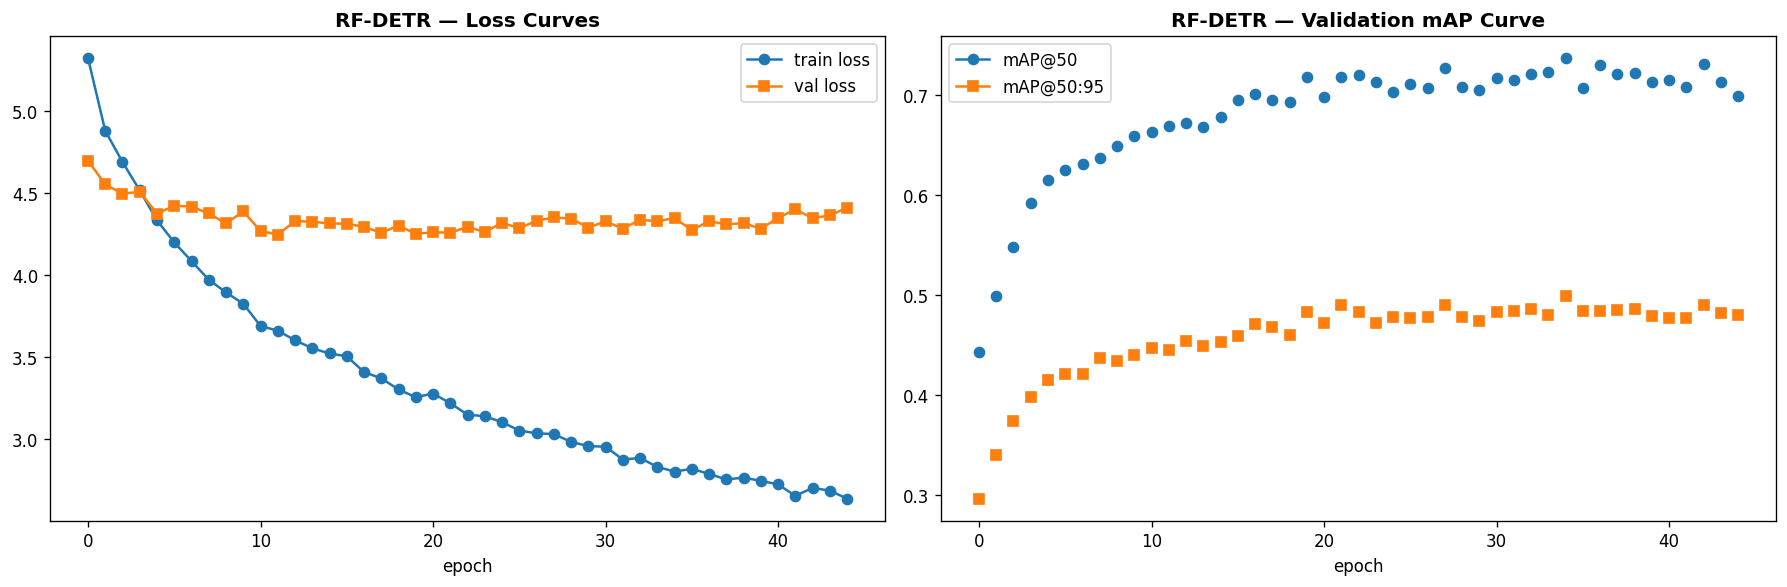

In [6]:
def load_rfdetr_log(out_dir):
    out_dir=pathlib.Path(out_dir)
    csvp = out_dir/"metrics.csv"
    if csvp.exists():
        df=pd.read_csv(csvp); df.columns=[c.strip() for c in df.columns]; return df, "csv"
    logp = out_dir/"log.txt"
    if logp.exists():
        rows=[]
        for line in open(logp):
            line=line.strip()
            if not line: continue
            try: rows.append(json.loads(line))
            except Exception: pass
        return pd.DataFrame(rows), "log"
    return None, None

dfh, kind = load_rfdetr_log(OUT_DIR)
if dfh is None:
    print("No metrics.csv / log.txt found — skipping curve plots (check output_dir).")
else:
    print("Parsed", kind, "with columns:", list(dfh.columns))   # full list, not truncated -- confirm names
    ep = dfh["epoch"] if "epoch" in dfh.columns else np.arange(len(dfh))

    def firstcol(cands):
        for c in cands:
            if c in dfh.columns: return dfh[c]
        return None

    # loss columns are logged at step-level (multiple NaN rows per epoch) --
    # aggregate to one value per epoch before plotting, mean() skips NaN automatically
    loss_tr = firstcol(["train_loss","loss","train/loss"])
    loss_va = firstcol(["test_loss","val_loss","validation_loss","val/loss"])
    loss_tr_series = dfh.groupby("epoch")[loss_tr.name].mean() if loss_tr is not None else None
    loss_va_series = dfh.groupby("epoch")[loss_va.name].mean() if loss_va is not None else None

    map5095 = firstcol(["test_map","map","metrics/mAP50-95","test/coco_map","val/mAP_50_95"])
    map50   = firstcol(["test_map_50","map50","metrics/mAP50","val/mAP_50"])
    coco_series=None
    if "test_coco_eval_bbox" in dfh.columns:
        try:
            arr=np.array([np.array(v, dtype=float) for v in dfh["test_coco_eval_bbox"]])
            map5095 = arr[:,0]; map50 = arr[:,1]
        except Exception as e: print("coco bbox parse note:", e)

    fig, ax = plt.subplots(1, 2, figsize=(15,5))
    if loss_tr_series is not None: ax[0].plot(loss_tr_series.index, loss_tr_series.values, marker="o", label="train loss")
    if loss_va_series is not None: ax[0].plot(loss_va_series.index, loss_va_series.values, marker="s", label="val loss")
    ax[0].set_title("RF-DETR — Loss Curves", fontweight="bold"); ax[0].set_xlabel("epoch"); ax[0].legend()
    if map50 is not None:   ax[1].plot(ep, map50, marker="o", label="mAP@50")
    if map5095 is not None: ax[1].plot(ep, map5095, marker="s", label="mAP@50:95")
    ax[1].set_title("RF-DETR — Validation mAP Curve", fontweight="bold"); ax[1].set_xlabel("epoch"); ax[1].legend()
    plt.tight_layout(); plt.show()

---
## 6. Load best model, build prediction cache & metric helpers
We load `best_rfdetr.pth`, run inference on the **test** split once at a low threshold (0.05), and
cache every prediction matched to ground truth by IoU. Self-contained AP / precision / recall
functions (no reliance on a specific supervision metrics API) then drive every downstream analysis
— mAP, per-class AP, ROC, confusion matrix, error analysis and robustness.


In [7]:
from rfdetr import RFDETRNano

def _round32(x):
    return max(32, int(round(x / 32) * 32))

RES_SAFE = _round32(RESOLUTION)
if RES_SAFE != RESOLUTION:
    print(f"RESOLUTION {RESOLUTION} not divisible by 32 -> using {RES_SAFE}")

try:
    infer_model = RFDETRNano(pretrain_weights=str(CKPT_OUT), resolution=RES_SAFE, num_classes=NUM_CLASSES)
except Exception as e:
    print("infer-model resolution note:", e)
    infer_model = RFDETRNano(pretrain_weights=str(CKPT_OUT), num_classes=NUM_CLASSES)

try:
    CLASS_NAMES_MODEL = list(infer_model.class_names)
except Exception:
    CLASS_NAMES_MODEL = None
print("model class_names:", CLASS_NAMES_MODEL)

TEST_IMG_DIR = COCO_ROOT/"test"
test_imgs = sorted([p for p in TEST_IMG_DIR.glob("*") if p.suffix.lower() in
                    {".jpg",".jpeg",".png",".bmp"}])
coco_test = json.load(open(TEST_IMG_DIR/"_annotations.coco.json"))
gt_by_file = defaultdict(list); id2wh={}
imgid2file={im["id"]:im["file_name"] for im in coco_test["images"]}
for im in coco_test["images"]: id2wh[im["file_name"]]=(im["width"],im["height"])
for a in coco_test["annotations"]:
    fn=imgid2file[a["image_id"]]; x,y,w,h=a["bbox"]
    gt_by_file[fn].append((a["category_id"]-1, [x,y,x+w,y+h]))   # 0-indexed class

def pred_to_idx(cid):
    # Map RF-DETR predicted class_id to our 0..6 index (robust to 0/1-indexing)
    if (cid+1) in CATID2NAME:           # predicted 0-indexed
        return cid
    if cid in CATID2NAME:               # predicted 1-indexed
        return cid-1
    return int(cid) % NUM_CLASSES

def iou_xyxy(a,b):
    ix1,iy1=max(a[0],b[0]),max(a[1],b[1]); ix2,iy2=min(a[2],b[2]),min(a[3],b[3])
    iw,ih=max(0,ix2-ix1),max(0,iy2-iy1); inter=iw*ih
    ua=(a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter
    return inter/ua if ua>0 else 0.0

# Low-threshold inference pass -> cache
CACHE=[]
LOW=0.05
for ip in test_imgs:
    img=Image.open(ip).convert("RGB")
    det=infer_model.predict(img, threshold=LOW, shape=(RES_SAFE, RES_SAFE))
    preds=[]
    if det.xyxy is not None and len(det.xyxy):
        for k in range(len(det.xyxy)):
            preds.append((pred_to_idx(int(det.class_id[k])), float(det.confidence[k]),
                          [float(v) for v in det.xyxy[k]]))
    CACHE.append({"file":ip.name, "preds":preds, "gts":gt_by_file.get(ip.name, [])})
print("Prediction cache built for", len(CACHE), "test images.")

def collect_class(cache, iou_t):
    # Per-class: list of (conf, is_tp) + n_gt, using greedy IoU matching at iou_t
    confs=defaultdict(list); tps=defaultdict(list); ngt=Counter()
    for rec in cache:
        for gc,_ in rec["gts"]: ngt[gc]+=1
    for rec in cache:
        preds=sorted(rec["preds"], key=lambda z:-z[1])
        gts=list(rec["gts"]); used=[False]*len(gts)
        for pc,ps,pb in preds:
            best,bj=iou_t,-1
            for j,(gc,gb) in enumerate(gts):
                if used[j] or gc!=pc: continue
                i=iou_xyxy(pb,gb)
                if i>=best: best,bj=i,j
            confs[pc].append(ps); tps[pc].append(1 if bj>=0 else 0)
            if bj>=0: used[bj]=True
    return confs,tps,ngt

def average_precision(conf,is_tp,n_gt):
    if n_gt==0 or len(conf)==0: return 0.0
    order=np.argsort(-np.array(conf)); tp=np.array(is_tp)[order]; fp=1-tp
    tpc=np.cumsum(tp); fpc=np.cumsum(fp)
    rec=tpc/max(n_gt,1); prec=tpc/np.clip(tpc+fpc,1,None)
    mrec=np.concatenate(([0],rec,[1])); mpre=np.concatenate(([0],prec,[0]))
    for i in range(len(mpre)-1,0,-1): mpre[i-1]=max(mpre[i-1],mpre[i])
    idx=np.where(mrec[1:]!=mrec[:-1])[0]
    return float(np.sum((mrec[idx+1]-mrec[idx])*mpre[idx+1]))

def map_at(cache, iou_t):
    confs,tps,ngt=collect_class(cache,iou_t); aps={}
    for ci in range(NUM_CLASSES):
        aps[ci]=average_precision(confs.get(ci,[]),tps.get(ci,[]),ngt.get(ci,0))
    return float(np.mean(list(aps.values()))), aps

print("Metric helpers ready.")

[2026-07-14 13:23:38] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-07-14 13:23:38] [WARNING] rf-detr - Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


RESOLUTION 560 not divisible by 32 -> using 576


[2026-07-14 13:23:39] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.
[2026-07-14 13:23:39] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.optimize_for_inference(dtype=torch.float16).


model class_names: ['Artilary', 'Missile', 'Radar', 'M. Rocket Launcher', 'Soldier', 'Tank', 'Vehicle']
Prediction cache built for 178 test images.
Metric helpers ready.


---
## 7. Test-split metrics (Task 5.6)
mAP@50 and mAP@50:95 (averaged over IoU 0.5→0.95), Precision / Recall / F1 at the operating
threshold, per-class AP, inference speed (FPS) and model cost.


In [8]:
mAP50, ap50_by = map_at(CACHE, 0.5)
ious=np.arange(0.5,1.0,0.05)
mAP5095=float(np.mean([map_at(CACHE,t)[0] for t in ious]))
per_class_ap50={CLASS_NAMES[c]:ap50_by[c] for c in range(NUM_CLASSES)}

# P / R / F1 at CONF_EVAL (single operating point, IoU 0.5)
TPc=FPc=FNc=0
for rec in CACHE:
    preds=sorted([p for p in rec["preds"] if p[1]>=CONF_EVAL], key=lambda z:-z[1])
    gts=list(rec["gts"]); used=[False]*len(gts)
    for pc,ps,pb in preds:
        best,bj=0.5,-1
        for j,(gc,gb) in enumerate(gts):
            if used[j] or gc!=pc: continue
            i=iou_xyxy(pb,gb)
            if i>=best: best,bj=i,j
        if bj>=0: used[bj]=True; TPc+=1
        else: FPc+=1
    FNc+=used.count(False)
PREC=TPc/max(TPc+FPc,1); REC=TPc/max(TPc+FNc,1)
F1=2*PREC*REC/max(PREC+REC,1e-9)

# FPS / latency
warm=test_imgs[:5]
for ip in warm: infer_model.predict(Image.open(ip).convert("RGB"), threshold=CONF_EVAL)
sample=test_imgs[:min(120,len(test_imgs))]
t0=time.time()
for ip in sample: infer_model.predict(Image.open(ip).convert("RGB"), threshold=CONF_EVAL)
dt=time.time()-t0
FPS=len(sample)/dt; LAT_MS=1000/FPS

# Params / size
try:
    torch_mod = getattr(infer_model, "model", infer_model)
    torch_mod = getattr(torch_mod, "model", torch_mod)
    N_PARAMS=int(sum(p.numel() for p in torch_mod.parameters()))
except Exception as e:
    print("param count note:", e); N_PARAMS=float("nan")
GFLOPS=float("nan")   # RF-DETR does not expose a simple fused-FLOPs count here
SIZE_MB=CKPT_OUT.stat().st_size/1e6

print("="*56); print("TEST-SPLIT RESULTS — RF-DETR nano"); print("="*56)
print(f"  mAP@50        : {mAP50:.4f}")
print(f"  mAP@50:95     : {mAP5095:.4f}")
print(f"  Precision     : {PREC:.4f}")
print(f"  Recall        : {REC:.4f}")
print(f"  F1-score      : {F1:.4f}")
print(f"  FPS           : {FPS:.1f}   (latency {LAT_MS:.2f} ms/img)")
print(f"  Params        : {N_PARAMS/1e6:.2f} M" if N_PARAMS==N_PARAMS else "  Params: n/a")
print(f"  Weights size  : {SIZE_MB:.1f} MB")
print("="*56)
for k,v in per_class_ap50.items(): print(f"  {k:20s} AP@50={v:.3f}")


TEST-SPLIT RESULTS — RF-DETR nano
  mAP@50        : 0.7537
  mAP@50:95     : 0.5260
  Precision     : 0.7240
  Recall        : 0.7060
  F1-score      : 0.7149
  FPS           : 20.6   (latency 48.57 ms/img)
  Params        : 30.45 M
  Weights size  : 121.9 MB
  Artilary             AP@50=0.879
  Missile              AP@50=0.650
  Radar                AP@50=0.566
  M. Rocket Launcher   AP@50=0.822
  Soldier              AP@50=0.841
  Tank                 AP@50=0.787
  Vehicle              AP@50=0.731


### 7.1 Class-wise AP bar chart


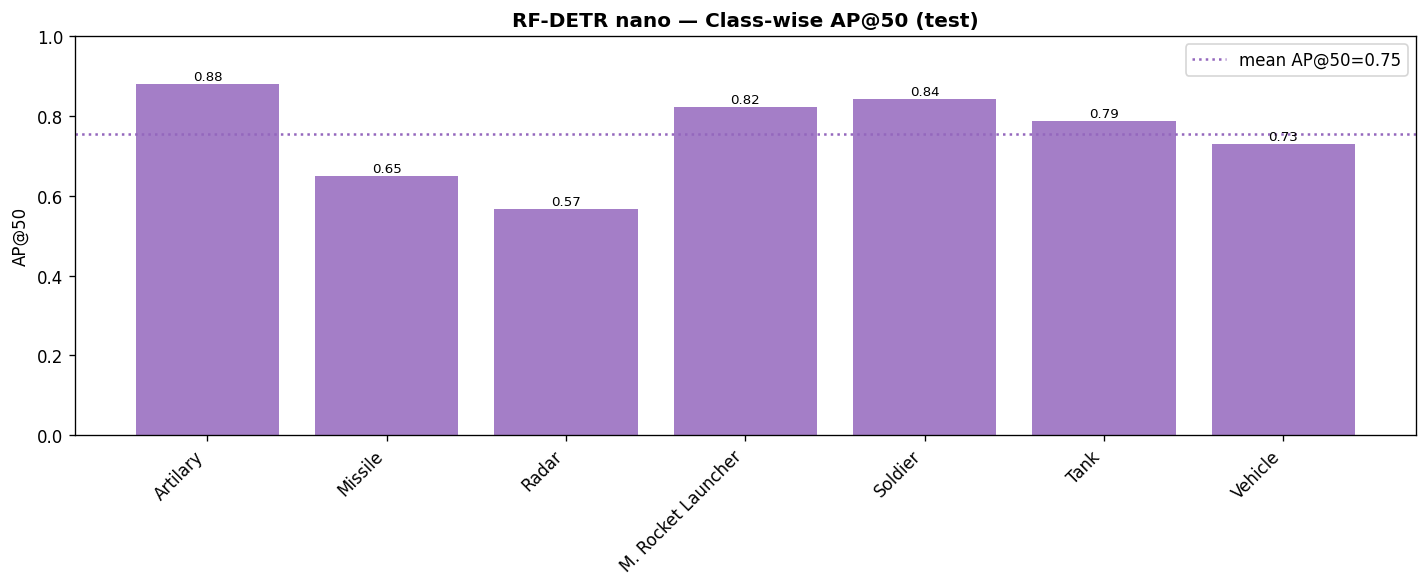

Strongest: Artilary (0.879) | Weakest: Radar (0.566)


In [9]:
names=CLASS_NAMES; ap50=[per_class_ap50[n] for n in names]
x=np.arange(len(names))
fig,axb=plt.subplots(figsize=(12,5))
b=axb.bar(x, ap50, color="tab:purple", alpha=.85)
axb.axhline(mAP50, color="tab:purple", ls=":", label=f"mean AP@50={mAP50:.2f}")
axb.set_xticks(x); axb.set_xticklabels(names, rotation=45, ha="right")
axb.set_ylim(0,1); axb.set_ylabel("AP@50")
axb.set_title("RF-DETR nano — Class-wise AP@50 (test)", fontweight="bold"); axb.legend()
for bar in b:
    h=bar.get_height(); axb.text(bar.get_x()+bar.get_width()/2, h+0.01, f"{h:.2f}",
                                 ha="center", fontsize=8)
plt.tight_layout(); plt.show()
worst=min(per_class_ap50,key=per_class_ap50.get); best=max(per_class_ap50,key=per_class_ap50.get)
print(f"Strongest: {best} ({per_class_ap50[best]:.3f}) | Weakest: {worst} ({per_class_ap50[worst]:.3f})")


### 7.2 ROC curves (detection-confidence ROC)
Same construction as the YOLO notebooks: each prediction is TP=1 (IoU≥0.5) else 0, scored by
confidence — measuring how well confidence separates true objects from false detections.


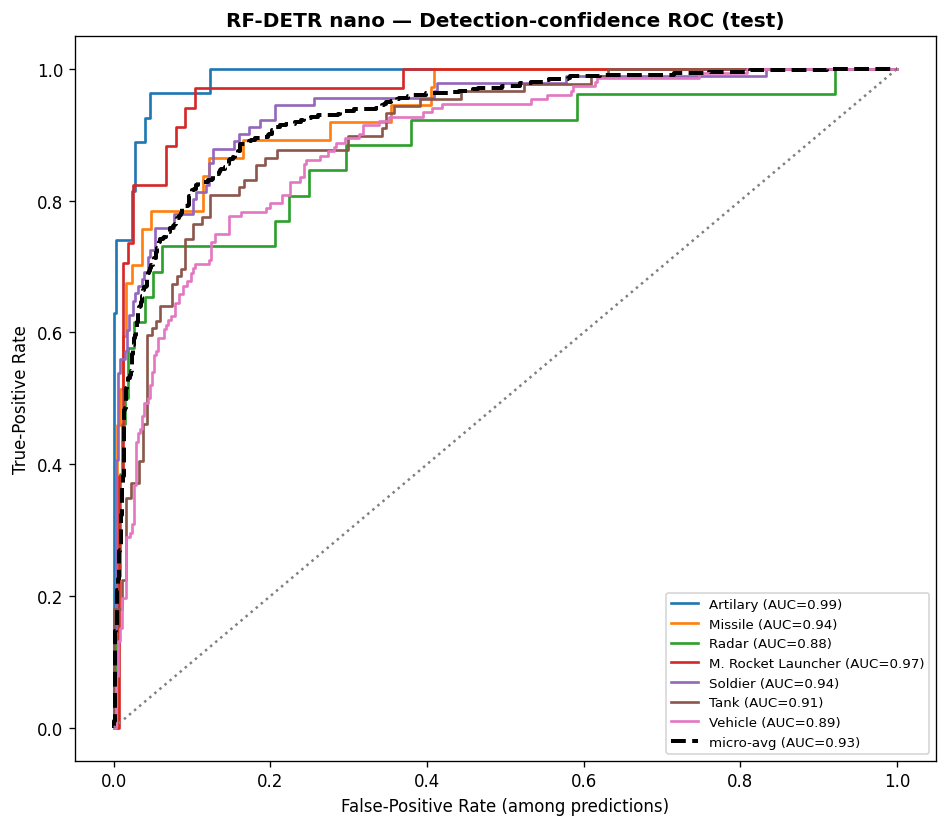

Per-class ROC AUC: {'Artilary': np.float64(0.988), 'Missile': np.float64(0.939), 'Radar': np.float64(0.879), 'M. Rocket Launcher': np.float64(0.968), 'Soldier': np.float64(0.94), 'Tank': np.float64(0.906), 'Vehicle': np.float64(0.888)}


In [10]:
from sklearn.metrics import roc_curve, auc
confs,tps,_=collect_class(CACHE,0.5)
fig,axr=plt.subplots(figsize=(8,7)); class_auc={}
all_s=[]; all_y=[]
for ci in range(NUM_CLASSES):
    y=tps.get(ci,[]); s=confs.get(ci,[])
    all_s+=s; all_y+=y
    if len(set(y))<2: continue
    fpr,tpr,_=roc_curve(y,s); a=auc(fpr,tpr); class_auc[CLASS_NAMES[ci]]=a
    axr.plot(fpr,tpr,lw=1.6,label=f"{CLASS_NAMES[ci]} (AUC={a:.2f})")
if len(set(all_y))>=2:
    fpr,tpr,_=roc_curve(all_y,all_s); micro=auc(fpr,tpr)
    axr.plot(fpr,tpr,"k--",lw=2.4,label=f"micro-avg (AUC={micro:.2f})")
axr.plot([0,1],[0,1],color="grey",ls=":")
axr.set_xlabel("False-Positive Rate (among predictions)"); axr.set_ylabel("True-Positive Rate")
axr.set_title("RF-DETR nano — Detection-confidence ROC (test)", fontweight="bold")
axr.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()
print("Per-class ROC AUC:", {k:round(v,3) for k,v in class_auc.items()})


### 7.3 Confusion matrix (test @ operating threshold)
With an explicit **background** row/column for missed objects and background false-alarms.


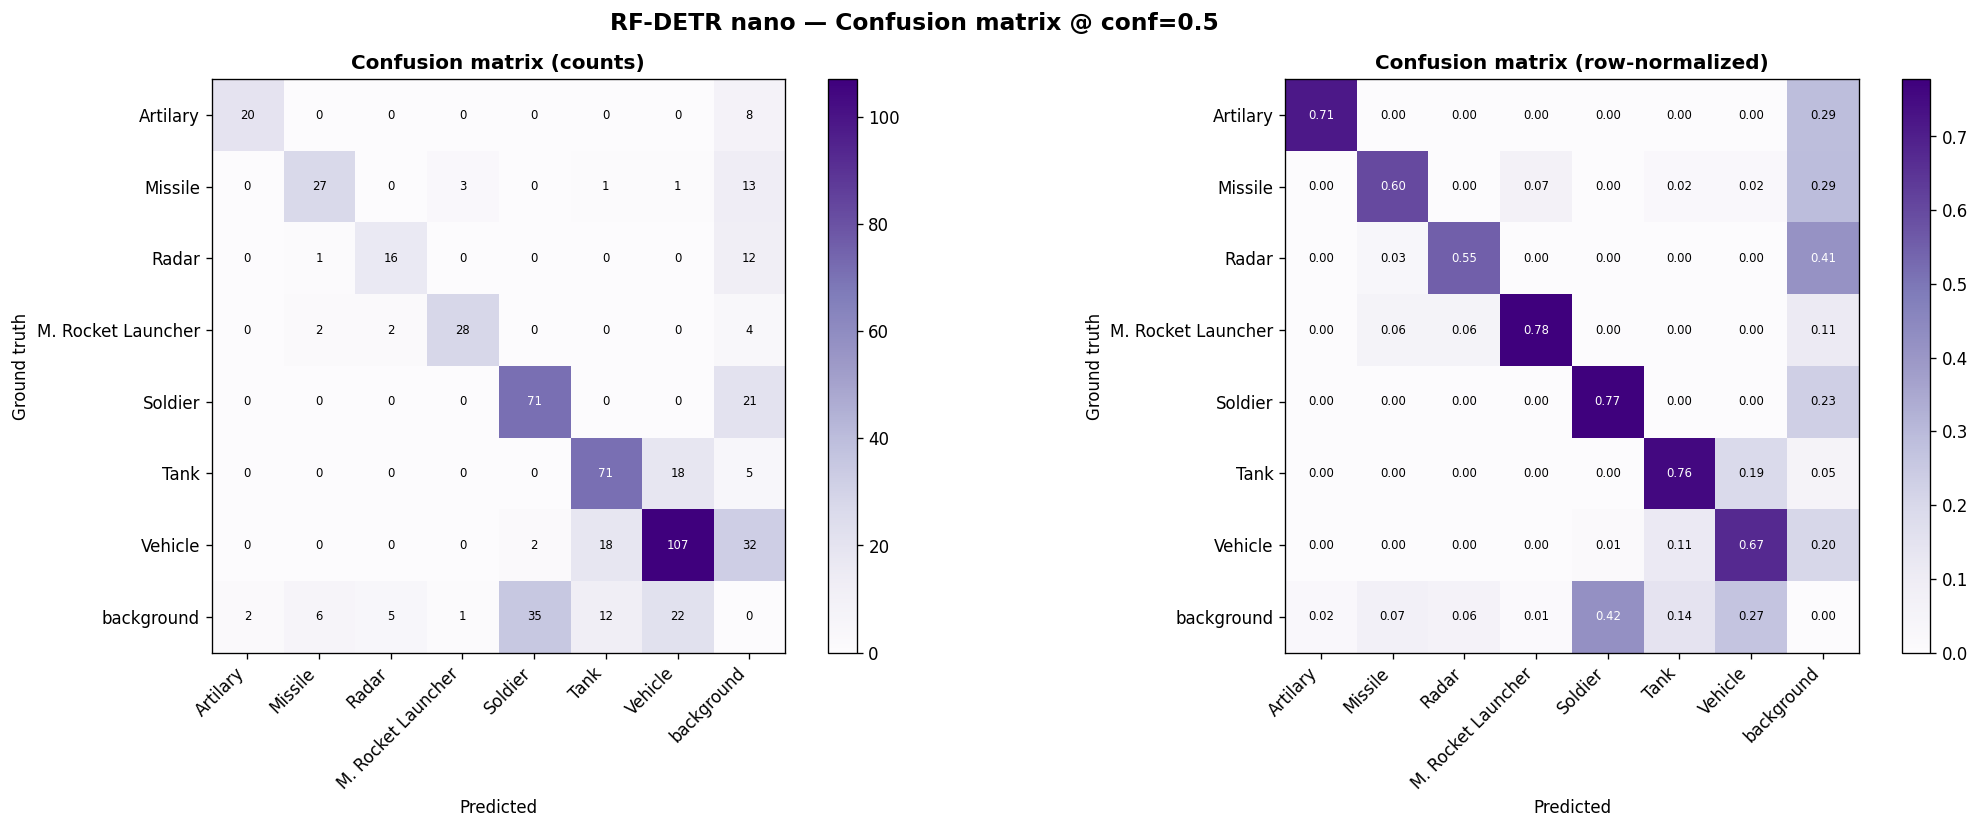

In [11]:
K=NUM_CLASSES; BG=K; cm=np.zeros((K+1,K+1),dtype=int)
for rec in CACHE:
    preds=sorted([p for p in rec["preds"] if p[1]>=CONF_EVAL], key=lambda z:-z[1])
    gts=list(rec["gts"]); used=[False]*len(gts)
    for pc,ps,pb in preds:
        best,bj=0.5,-1
        for j,(gc,gb) in enumerate(gts):
            if used[j]: continue
            i=iou_xyxy(pb,gb)
            if i>=best: best,bj=i,j
        if bj>=0: used[bj]=True; cm[gts[bj][0],pc]+=1
        else: cm[BG,pc]+=1
    for j,(gc,gb) in enumerate(gts):
        if not used[j]: cm[gc,BG]+=1
labels_cm=CLASS_NAMES+["background"]
cmn=cm/np.clip(cm.sum(axis=1,keepdims=True),1,None)
fig,axc=plt.subplots(1,2,figsize=(18,7))
for a,mat,ttl,fmt in [(axc[0],cm,"counts","d"),(axc[1],cmn,"row-normalized",".2f")]:
    im=a.imshow(mat,cmap="Purples"); a.figure.colorbar(im,ax=a,fraction=0.046)
    a.set_xticks(range(K+1)); a.set_yticks(range(K+1))
    a.set_xticklabels(labels_cm,rotation=45,ha="right"); a.set_yticklabels(labels_cm)
    a.set_xlabel("Predicted"); a.set_ylabel("Ground truth"); a.set_title(f"Confusion matrix ({ttl})",fontweight="bold")
    thr=mat.max()/2
    for i in range(K+1):
        for j in range(K+1):
            v=mat[i,j]; a.text(j,i,format(v,fmt),ha="center",va="center",fontsize=7,
                               color="white" if v>thr else "black")
plt.suptitle(f"RF-DETR nano — Confusion matrix @ conf={CONF_EVAL}", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()


---
## 8. Qualitative detection results
Left = ground truth (green), right = RF-DETR predictions (conf≥threshold, colored by class).


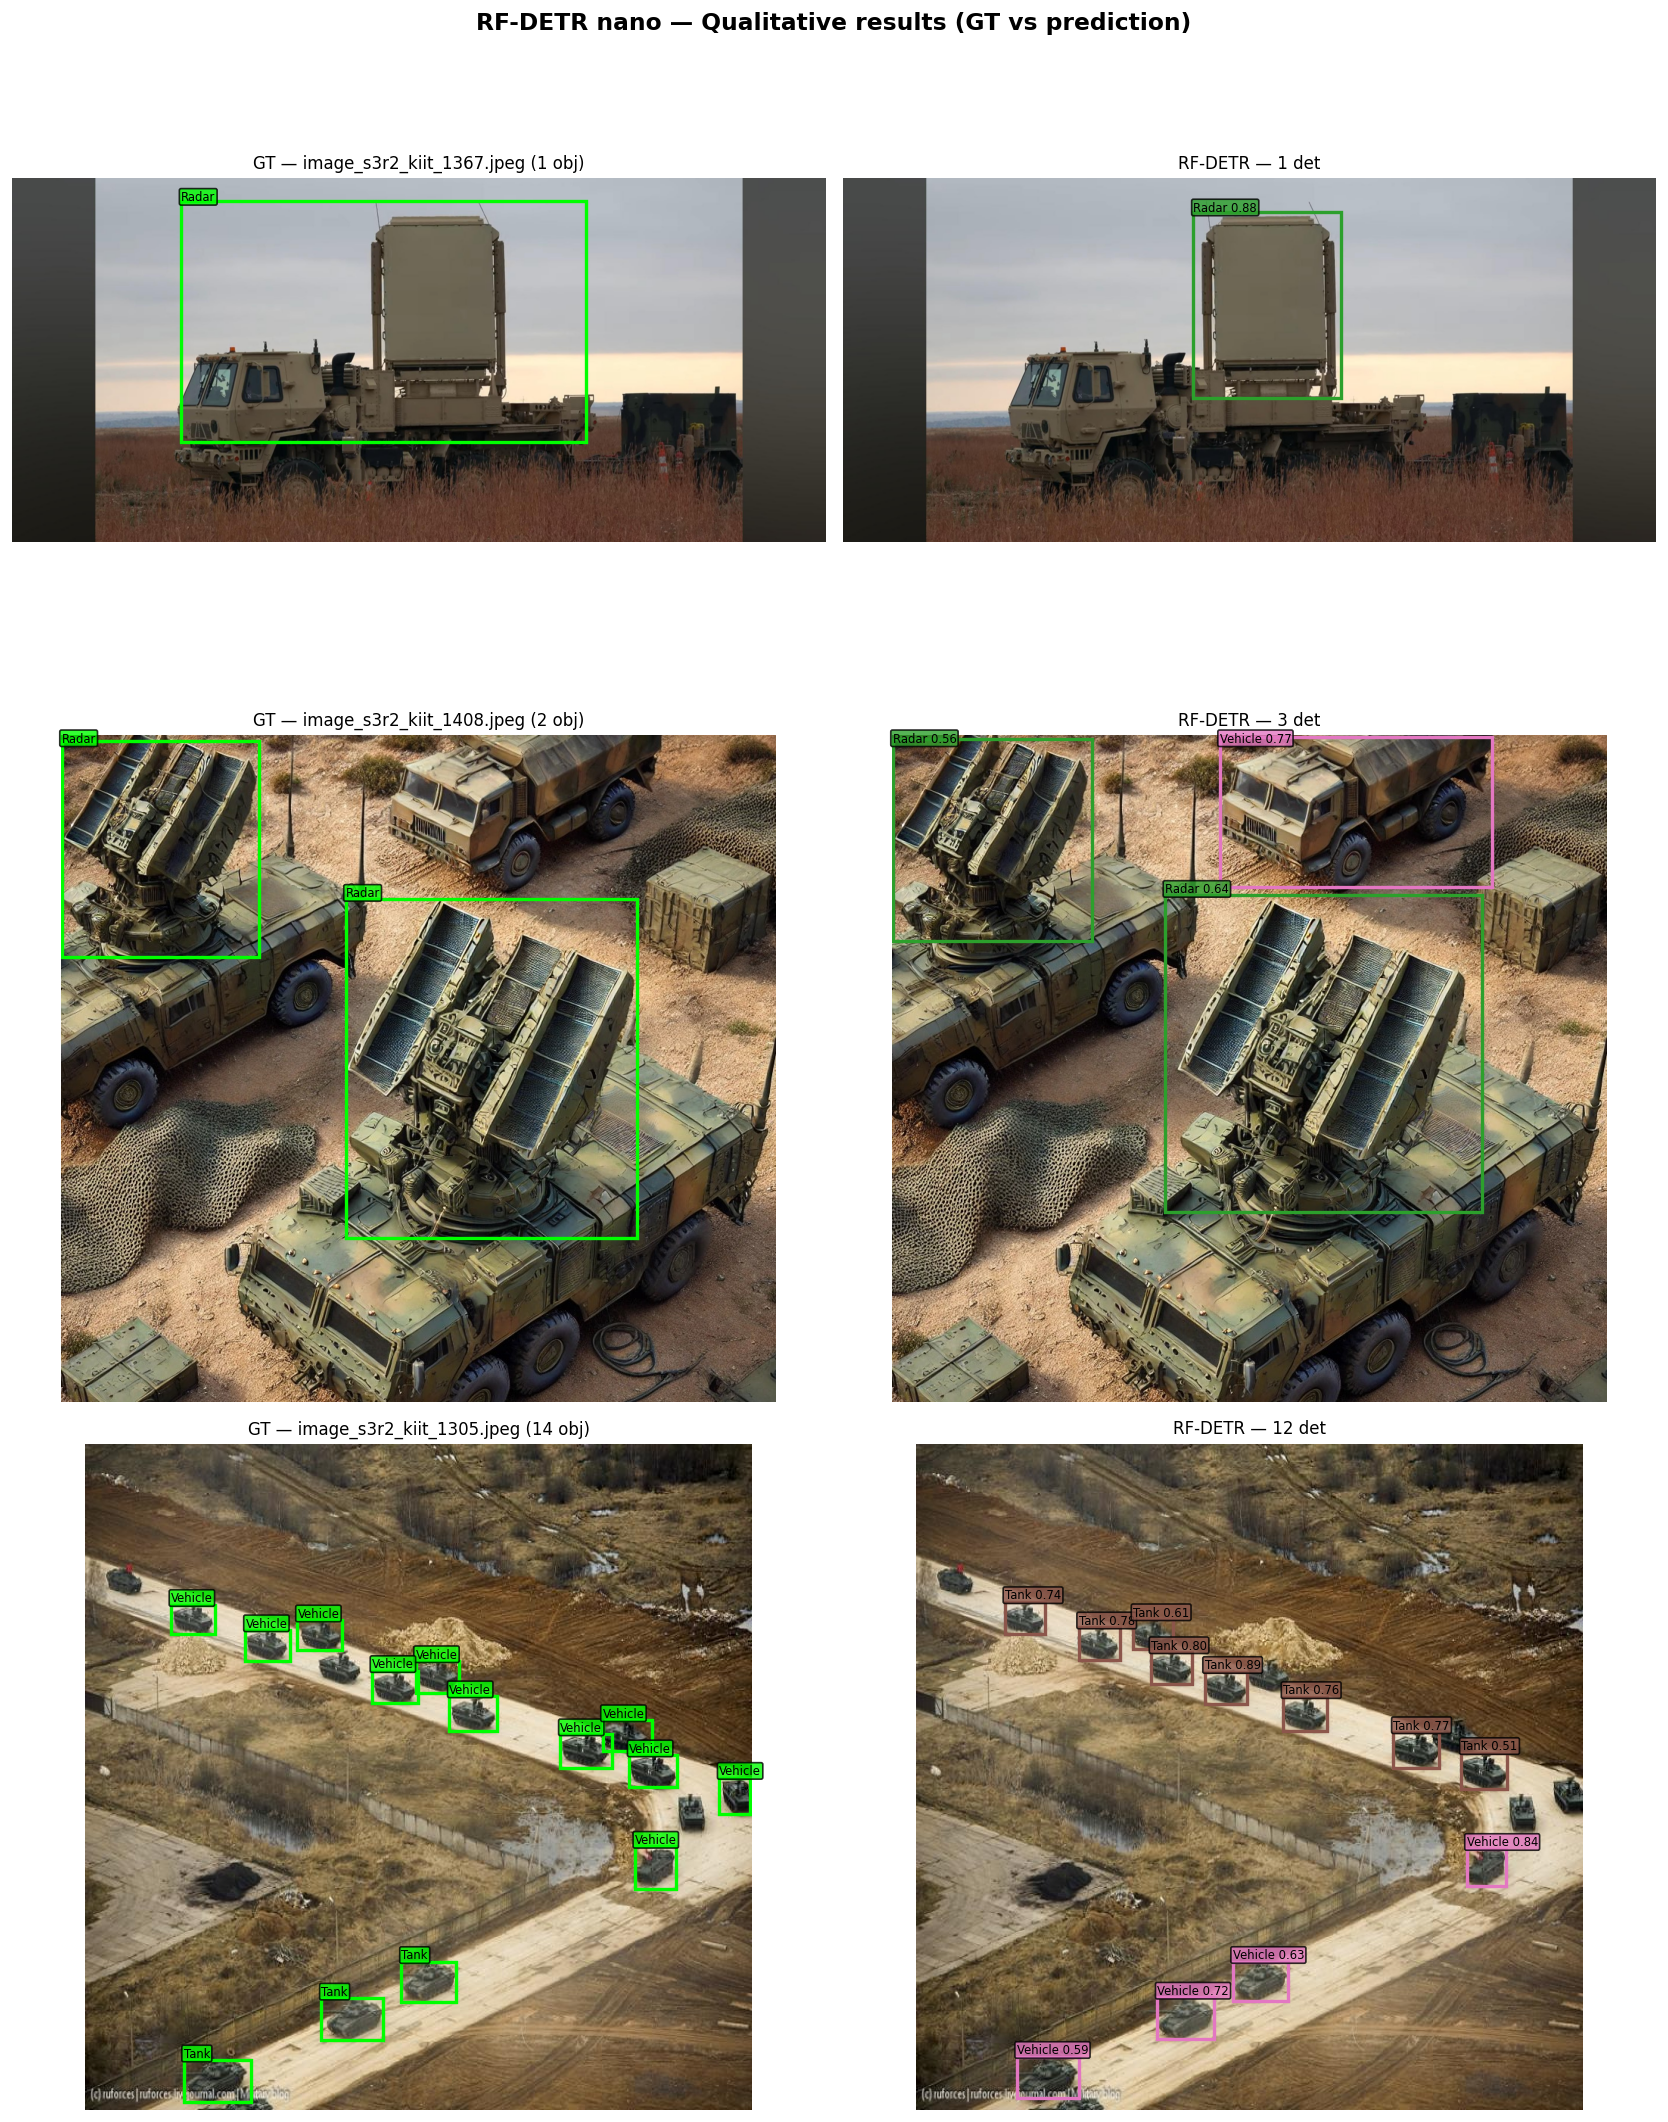

In [12]:
pal=plt.get_cmap("tab10")
def draw(ax,img,boxes,title,gt=False):
    ax.imshow(img)
    for item in boxes:
        if gt: c,xy=item; sc=None
        else:  c,sc,xy=item
        col="lime" if gt else pal(c%10); x1,y1,x2,y2=xy
        ax.add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor=col,lw=2))
        lab=CLASS_NAMES[c]+("" if gt else f" {sc:.2f}")
        ax.text(x1,max(y1-3,8),lab,fontsize=7,color="black",
                bbox=dict(boxstyle="round,pad=0.15",fc=col,alpha=.8))
    ax.set_title(title,fontsize=10); ax.axis("off")

byd=sorted(CACHE,key=lambda r:len(r["gts"]))
picks=[byd[len(byd)//10], byd[len(byd)//2], byd[-1]]
fig,ax=plt.subplots(3,2,figsize=(14,18))
for row,rec in enumerate(picks):
    img=np.array(Image.open(TEST_IMG_DIR/rec["file"]).convert("RGB"))
    preds=[(c,s,b) for (c,s,b) in rec["preds"] if s>=CONF_EVAL]
    draw(ax[row,0],img,rec["gts"],f"GT — {rec['file']} ({len(rec['gts'])} obj)",gt=True)
    draw(ax[row,1],img,preds,f"RF-DETR — {len(preds)} det",gt=False)
plt.suptitle("RF-DETR nano — Qualitative results (GT vs prediction)",fontsize=14,fontweight="bold")
plt.tight_layout(); plt.show()


---
## 9. Error analysis (Task 5.7)
≥3 false negatives, ≥3 false positives (with an automatic cause label) and a data-driven
failure-pattern summary — the same methodology as the YOLO notebooks so the comparison in §13 is
apples-to-apples.


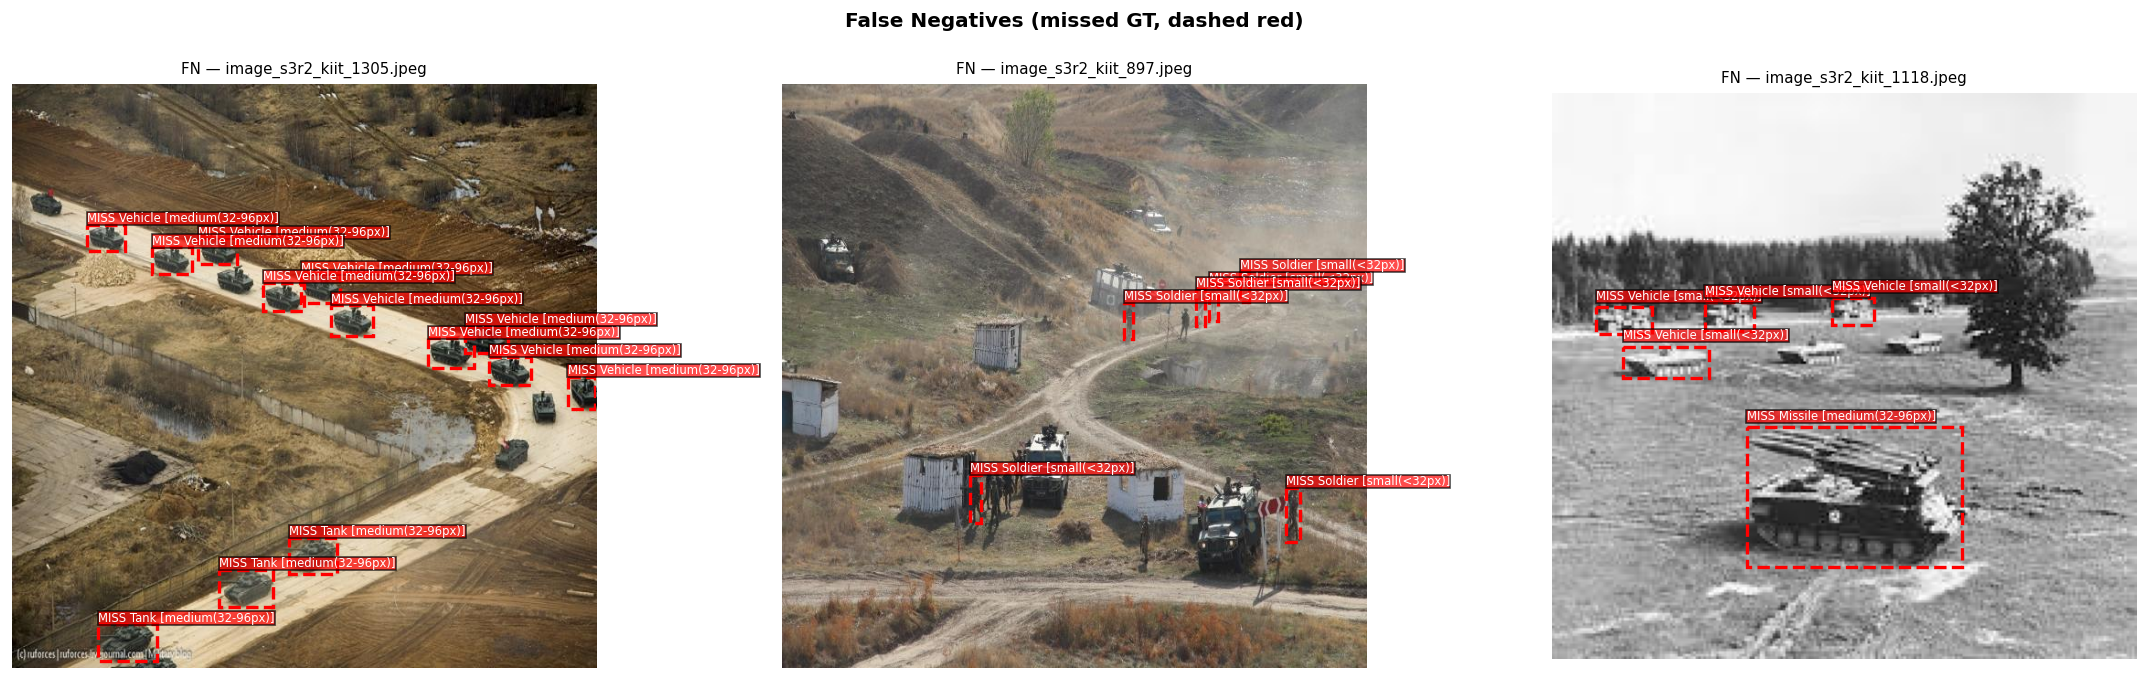

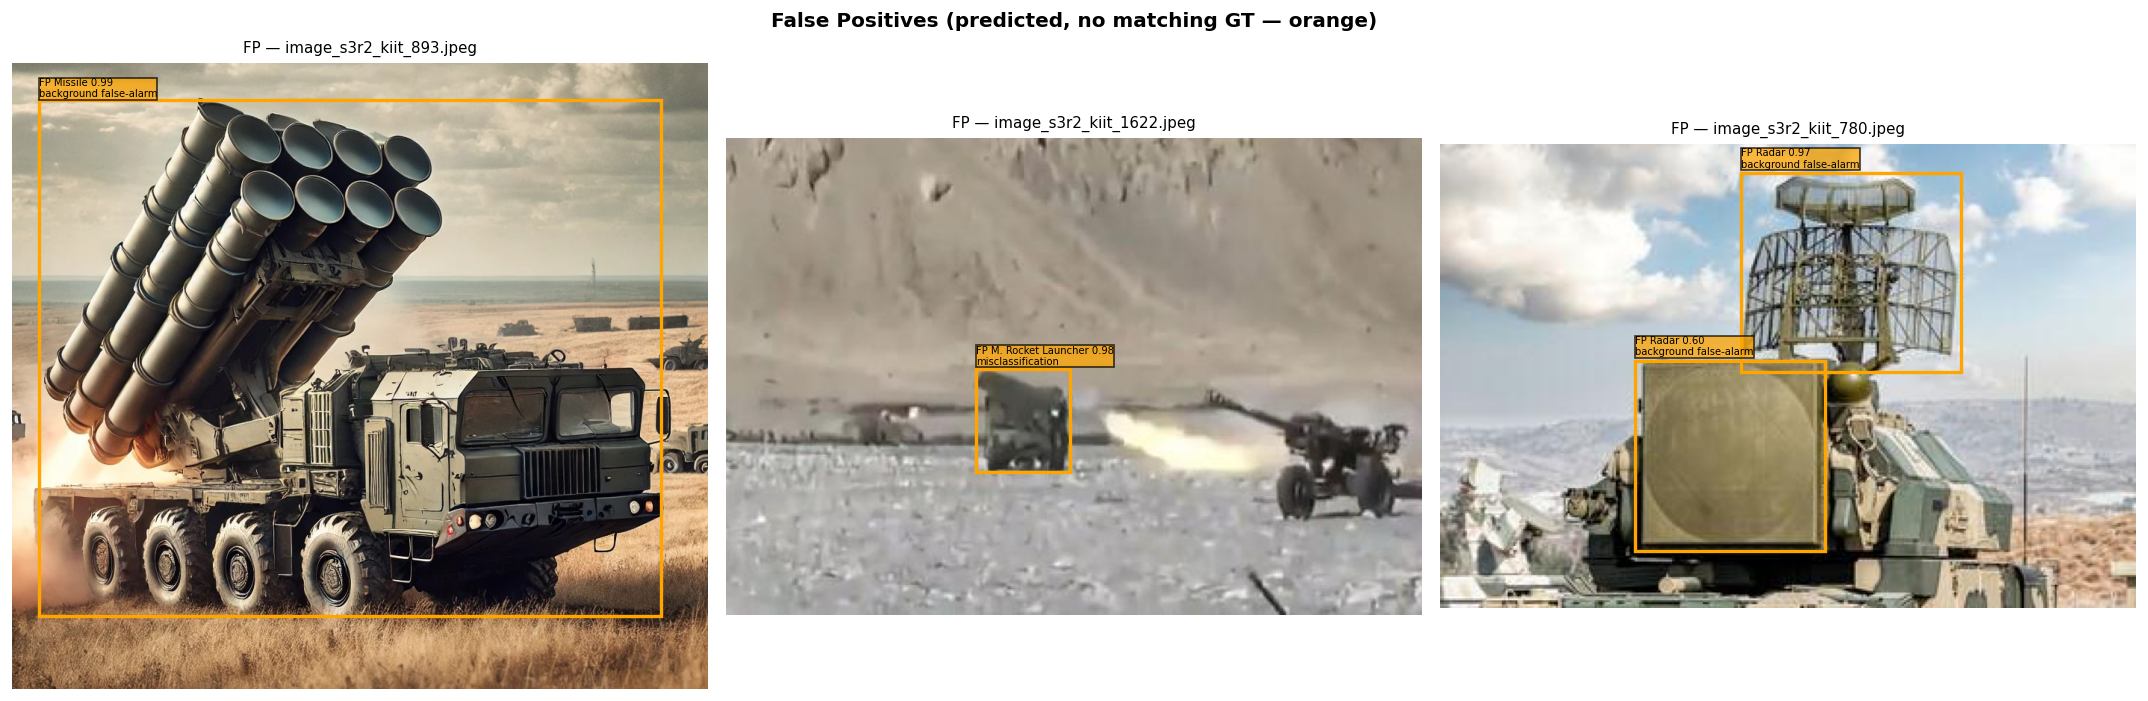

FAILURE-PATTERN SUMMARY — RF-DETR nano
Total FN: 142 | Total FP: 130
Most-missed class (FN): [('Vehicle', 52)]
Most false-alarmed class (FP): [('Vehicle', 41)]
Small-object share of FN: 20%
Misclassification share of FP: 41%

>>> Unlike the YOLO anchors, RF-DETR's set-prediction (bipartite-matching, NMS-free) head
    tends to avoid duplicate boxes but can under-detect in very dense clusters (fixed query
    budget). Compare this pattern against the YOLO failure summaries in Notebooks 2-4.


In [13]:
def match_image(rec, conf_thr):
    preds=sorted([p for p in rec["preds"] if p[1]>=conf_thr], key=lambda z:-z[1])
    gts=list(rec["gts"]); used=[False]*len(gts); tp,fp=[],[]
    for pc,ps,pb in preds:
        best,bj=0.5,-1
        for j,(gc,gb) in enumerate(gts):
            if used[j] or gc!=pc: continue
            i=iou_xyxy(pb,gb)
            if i>=best: best,bj=i,j
        if bj>=0: used[bj]=True; tp.append((pc,ps))
        else: fp.append((pc,ps,pb))
    fn=[gts[j] for j in range(len(gts)) if not used[j]]
    return tp,fp,fn

area_of=lambda b:(b[2]-b[0])*(b[3]-b[1])
fn_records,fp_records=[],[]
for rec in CACHE:
    _,fp,fn=match_image(rec,CONF_EVAL)
    for gc,gb in fn: fn_records.append({"file":rec["file"],"cls":gc,"box":gb,"area":area_of(gb)})
    for pc,ps,pb in fp:
        mis=any(iou_xyxy(pb,gb)>=0.5 and gc!=pc for gc,gb in rec["gts"])
        fp_records.append({"file":rec["file"],"cls":pc,"score":ps,"box":pb,
                           "cause":"misclassification" if mis else "background false-alarm"})

acat=lambda a:"small(<32px)" if a**0.5<32 else ("medium(32-96px)" if a**0.5<96 else "large(>96px)")
fn_imgs=[f for f,_ in Counter(r["file"] for r in fn_records).most_common(3)]
fig,ax=plt.subplots(1,3,figsize=(18,6))
for i,f in enumerate(fn_imgs):
    img=np.array(Image.open(TEST_IMG_DIR/f).convert("RGB")); ax[i].imshow(img)
    for r in [r for r in fn_records if r["file"]==f]:
        x1,y1,x2,y2=r["box"]
        ax[i].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor="red",lw=2,ls="--"))
        ax[i].text(x1,max(y1-3,8),f"MISS {CLASS_NAMES[r['cls']]} [{acat(r['area'])}]",fontsize=7,
                   color="white",bbox=dict(fc="red",alpha=.7,pad=0.1))
    ax[i].set_title(f"FN — {f}",fontsize=9); ax[i].axis("off")
plt.suptitle("False Negatives (missed GT, dashed red)",fontweight="bold"); plt.tight_layout(); plt.show()

fp_sorted=sorted(fp_records,key=lambda r:-r["score"]); fp_show,seen=[],set()
for r in fp_sorted:
    if r["file"] in seen: continue
    fp_show.append(r); seen.add(r["file"])
    if len(fp_show)==3: break
fig,ax=plt.subplots(1,3,figsize=(18,6))
for i,r in enumerate(fp_show):
    img=np.array(Image.open(TEST_IMG_DIR/r["file"]).convert("RGB")); ax[i].imshow(img)
    for rr in [z for z in fp_records if z["file"]==r["file"]][:6]:
        x1,y1,x2,y2=rr["box"]
        ax[i].add_patch(patches.Rectangle((x1,y1),x2-x1,y2-y1,fill=False,edgecolor="orange",lw=2))
        ax[i].text(x1,max(y1-3,8),f"FP {CLASS_NAMES[rr['cls']]} {rr['score']:.2f}\n{rr['cause']}",
                   fontsize=6,color="black",bbox=dict(fc="orange",alpha=.75,pad=0.1))
    ax[i].set_title(f"FP — {r['file']}",fontsize=9); ax[i].axis("off")
plt.suptitle("False Positives (predicted, no matching GT — orange)",fontweight="bold")
plt.tight_layout(); plt.show()

fn_cls=Counter(CLASS_NAMES[r["cls"]] for r in fn_records)
fp_cls=Counter(CLASS_NAMES[r["cls"]] for r in fp_records)
small_fn=sum(1 for r in fn_records if r["area"]**0.5<32); tot_fn=max(len(fn_records),1)
mis_fp=sum(1 for r in fp_records if r["cause"]=="misclassification"); tot_fp=max(len(fp_records),1)
print("="*60); print("FAILURE-PATTERN SUMMARY — RF-DETR nano"); print("="*60)
print(f"Total FN: {len(fn_records)} | Total FP: {len(fp_records)}")
print(f"Most-missed class (FN): {fn_cls.most_common(1)}")
print(f"Most false-alarmed class (FP): {fp_cls.most_common(1)}")
print(f"Small-object share of FN: {small_fn/tot_fn*100:.0f}%")
print(f"Misclassification share of FP: {mis_fp/tot_fp*100:.0f}%")
print("\n>>> Unlike the YOLO anchors, RF-DETR's set-prediction (bipartite-matching, NMS-free) head")
print("    tends to avoid duplicate boxes but can under-detect in very dense clusters (fixed query")
print("    budget). Compare this pattern against the YOLO failure summaries in Notebooks 2-4.")


---
## 10. Robustness analysis
Same five corruptions × three severities as the YOLO notebooks; mAP@50 is recomputed from a
corrupted prediction cache so the robustness curves are directly comparable across all four models.


clean mAP@50 on 120 imgs = 0.759
  gaussian_noise   sev1: mAP@50=0.709 (  93%)
  gaussian_noise   sev2: mAP@50=0.694 (  91%)
  gaussian_noise   sev3: mAP@50=0.624 (  82%)
  gaussian_blur    sev1: mAP@50=0.741 (  98%)
  gaussian_blur    sev2: mAP@50=0.692 (  91%)
  gaussian_blur    sev3: mAP@50=0.662 (  87%)
  brightness_down  sev1: mAP@50=0.736 (  97%)
  brightness_down  sev2: mAP@50=0.735 (  97%)
  brightness_down  sev3: mAP@50=0.721 (  95%)
  contrast         sev1: mAP@50=0.732 (  96%)
  contrast         sev2: mAP@50=0.718 (  95%)
  contrast         sev3: mAP@50=0.682 (  90%)
  jpeg             sev1: mAP@50=0.731 (  96%)
  jpeg             sev2: mAP@50=0.692 (  91%)
  jpeg             sev3: mAP@50=0.624 (  82%)


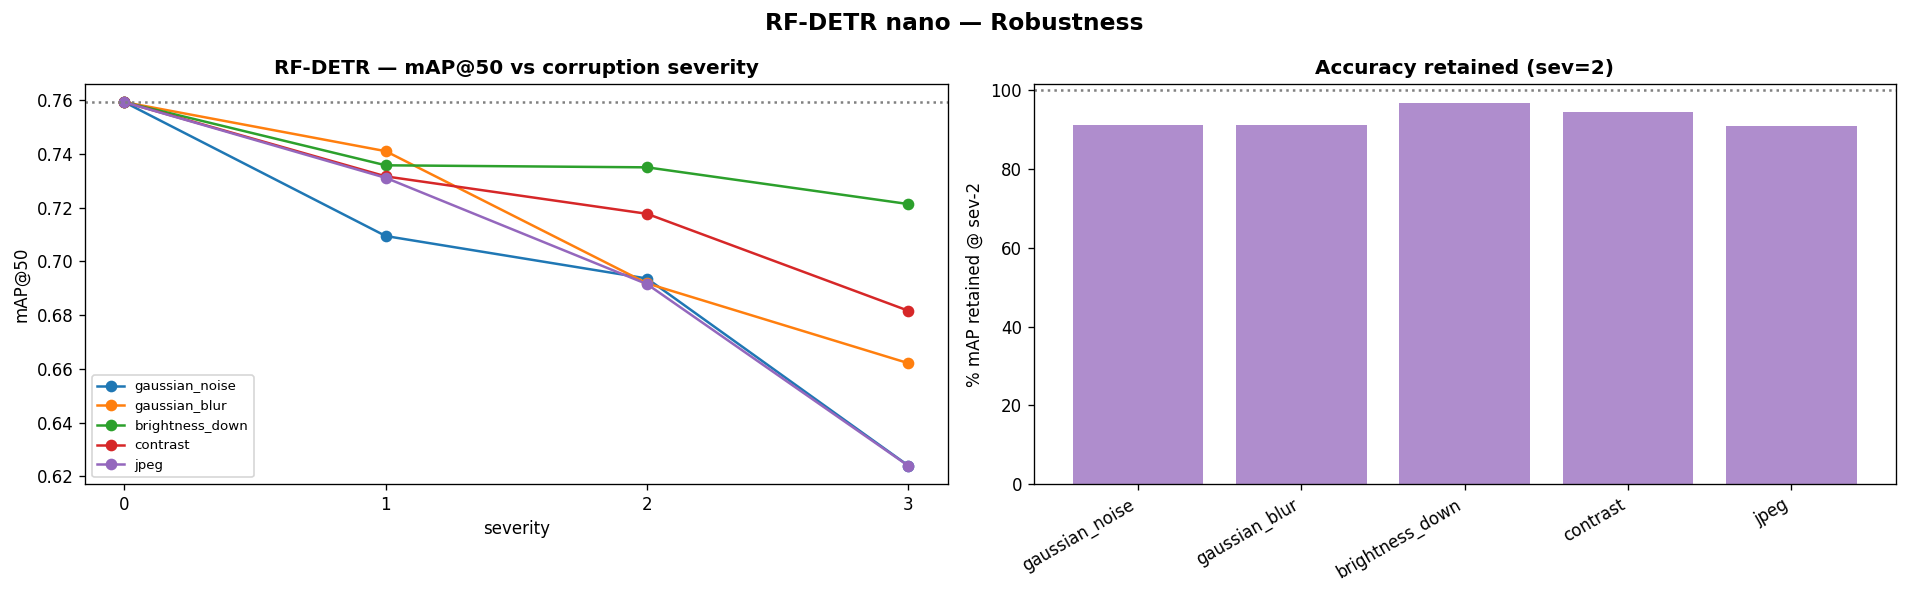

Least robust: jpeg (91% retained)


In [14]:
N_ROBUST=min(120,len(test_imgs)); rob_imgs=test_imgs[:N_ROBUST]
def c_noise(im,s): std=[8,18,32][s-1]; return np.clip(im+np.random.normal(0,std,im.shape),0,255).astype(np.uint8)
def c_blur(im,s):  k=[3,7,11][s-1]; return cv2.GaussianBlur(im,(k,k),0)
def c_dark(im,s):  f=[0.7,0.5,0.35][s-1]; return np.clip(im*f,0,255).astype(np.uint8)
def c_contrast(im,s): f=[0.6,0.4,0.25][s-1]; m=im.mean(); return np.clip((im-m)*f+m,0,255).astype(np.uint8)
def c_jpeg(im,s):
    q=[40,25,12][s-1]; ok,e=cv2.imencode(".jpg",cv2.cvtColor(im,cv2.COLOR_RGB2BGR),[cv2.IMWRITE_JPEG_QUALITY,q])
    return cv2.cvtColor(cv2.imdecode(e,1),cv2.COLOR_BGR2RGB)
CORR={"gaussian_noise":c_noise,"gaussian_blur":c_blur,"brightness_down":c_dark,
      "contrast":c_contrast,"jpeg":c_jpeg}

def cache_for(imgs, fn=None, sev=1):
    out=[]
    for ip in imgs:
        arr=np.array(Image.open(ip).convert("RGB")); arr=arr if fn is None else fn(arr,sev)
        det=infer_model.predict(Image.fromarray(arr), threshold=LOW)
        preds=[]
        if det.xyxy is not None and len(det.xyxy):
            for k in range(len(det.xyxy)):
                preds.append((pred_to_idx(int(det.class_id[k])),float(det.confidence[k]),
                              [float(v) for v in det.xyxy[k]]))
        out.append({"file":ip.name,"preds":preds,"gts":gt_by_file.get(ip.name,[])})
    return out

base_map=map_at(cache_for(rob_imgs),0.5)[0]
print(f"clean mAP@50 on {N_ROBUST} imgs = {base_map:.3f}")
rob={}
for cn,fn in CORR.items():
    rob[cn]={}
    for s in [1,2,3]:
        m=map_at(cache_for(rob_imgs,fn,s),0.5)[0]; rob[cn][s]=m
        print(f"  {cn:16s} sev{s}: mAP@50={m:.3f} ({m/max(base_map,1e-6)*100:4.0f}%)")

fig,ax=plt.subplots(1,2,figsize=(16,5))
for cn in CORR:
    ax[0].plot([0,1,2,3],[base_map]+[rob[cn][s] for s in [1,2,3]],marker="o",label=cn)
ax[0].axhline(base_map,color="grey",ls=":"); ax[0].set_xlabel("severity"); ax[0].set_ylabel("mAP@50")
ax[0].set_title("RF-DETR — mAP@50 vs corruption severity",fontweight="bold"); ax[0].set_xticks([0,1,2,3]); ax[0].legend(fontsize=8)
ret={c:rob[c][2]/max(base_map,1e-6)*100 for c in CORR}
ax[1].bar(list(ret.keys()),list(ret.values()),color="tab:purple",alpha=.75); ax[1].axhline(100,color="grey",ls=":")
ax[1].set_ylabel("% mAP retained @ sev-2"); ax[1].set_title("Accuracy retained (sev=2)",fontweight="bold")
ax[1].set_xticklabels(list(ret.keys()),rotation=30,ha="right")
plt.suptitle("RF-DETR nano — Robustness",fontsize=14,fontweight="bold"); plt.tight_layout(); plt.show()
print("Least robust:",min(ret,key=ret.get),f"({ret[min(ret,key=ret.get)]:.0f}% retained)")


---
## 11. Persist checkpoint & export metrics


In [15]:
summary={"model_key":MODEL_KEY,"model_slug":MODEL_SLUG,"size":VARIANT,"weight":"rfdetr-nano",
    "epochs_config":EPOCHS,"img_size":RESOLUTION,"batch":BATCH_SIZE*GRAD_ACCUM,
    "map50":mAP50,"map5095":mAP5095,"precision":PREC,"recall":REC,"f1":F1,
    "fps_infer":FPS,"fps_e2e":FPS,"latency_ms":LAT_MS,
    "params_millions":(N_PARAMS/1e6 if N_PARAMS==N_PARAMS else None),"gflops":None,
    "size_mb":SIZE_MB,"train_minutes":float(TRAIN_MINUTES),
    "per_class_ap50":per_class_ap50,"roc_auc":class_auc,
    "robustness_map50":rob,"robust_retained_sev2":ret,"checkpoint":str(CKPT_OUT)}
for dst in [METRICS_OUT, COMPARE_DIR/"results_rfdetr.json"]:
    json.dump(summary, open(dst,"w"), indent=2, default=lambda x: (float(x) if isinstance(x,(int,float)) else x))
print("Saved ->", METRICS_OUT, "and", COMPARE_DIR/"results_rfdetr.json")


Saved -> /kaggle/working/results_rfdetr.json and /kaggle/working/model_compare/results_rfdetr.json


---
## 12. Cross-model comparison — YOLOv10 · YOLOv12 · YOLOv26 · RF-DETR
This section loads each model's `results_<slug>.json` (from Notebooks 2–5) and builds the full
comparison suite: a **comparison table**, **mAP bar chart**, **FPS-vs-mAP**, **latency-vs-accuracy**,
**parameters-vs-mAP** scatters, plus **inference-time**, **model-size**, **FLOPs**, **training-time**
and **robustness** comparisons.

> To populate all four rows, attach the committed outputs of Notebooks 2–4 as inputs to this
> notebook. Any missing model is simply skipped (the charts still render for whatever is present).


Models found: ['YOLOv10', 'YOLOv12', 'YOLOv26', 'RF-DETR']

=== MODEL COMPARISON TABLE ===


,mAP@50,mAP@50:95,Precision,Recall,F1,FPS,Latency(ms),Params(M),GFLOPs,Size(MB),Train(min)
Model,,,,,,,,,,,
YOLOv10,0.646,0.421,0.673,0.600,0.635,84.745,11.800,7.221,NaN,16.522,73.675
YOLOv12,0.665,0.432,0.631,0.636,0.633,71.176,14.050,9.234,NaN,18.925,91.791
YOLOv26,0.648,0.460,0.722,0.624,0.669,82.070,12.185,9.468,NaN,20.311,85.962
RF-DETR,0.754,0.526,0.724,0.706,0.715,20.589,48.570,30.445,NaN,121.876,396.136


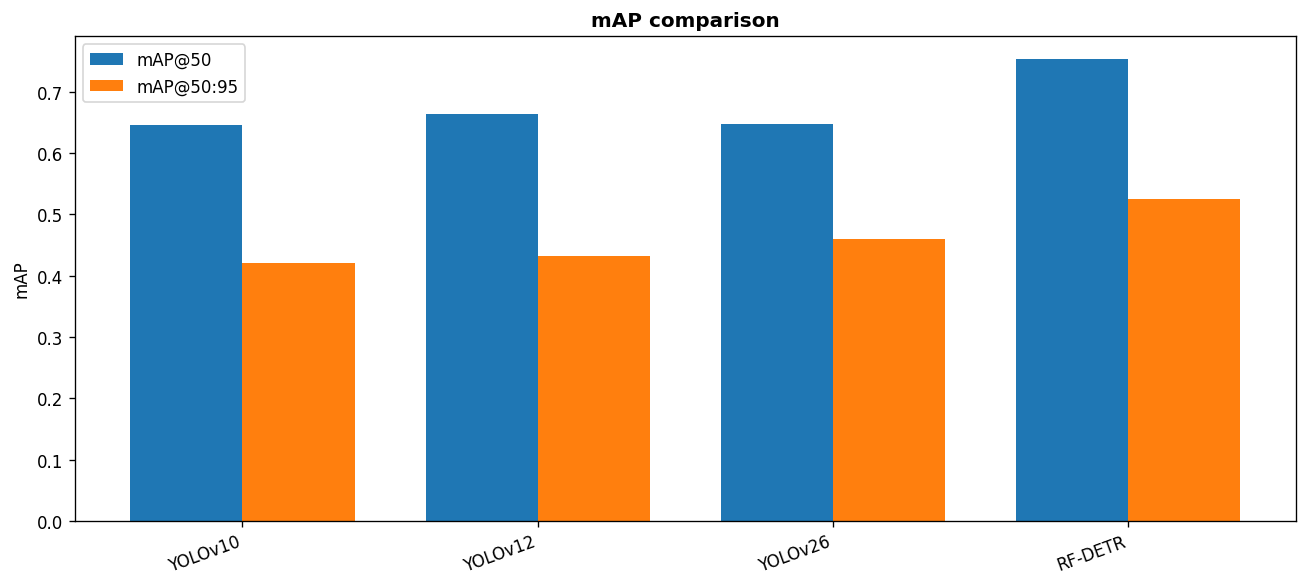

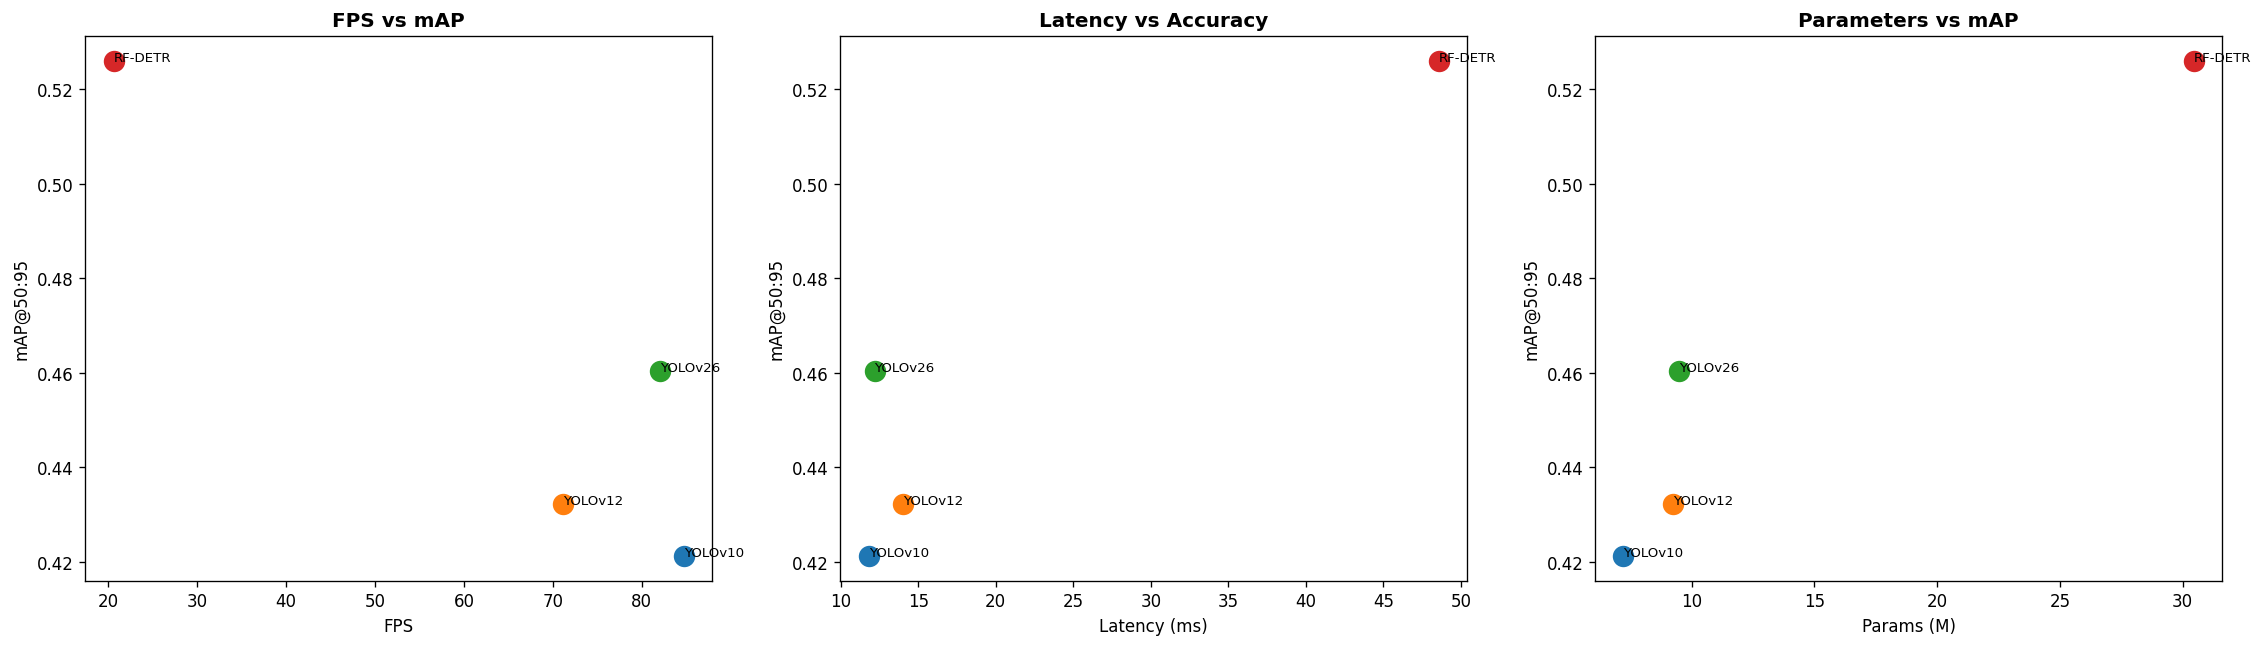

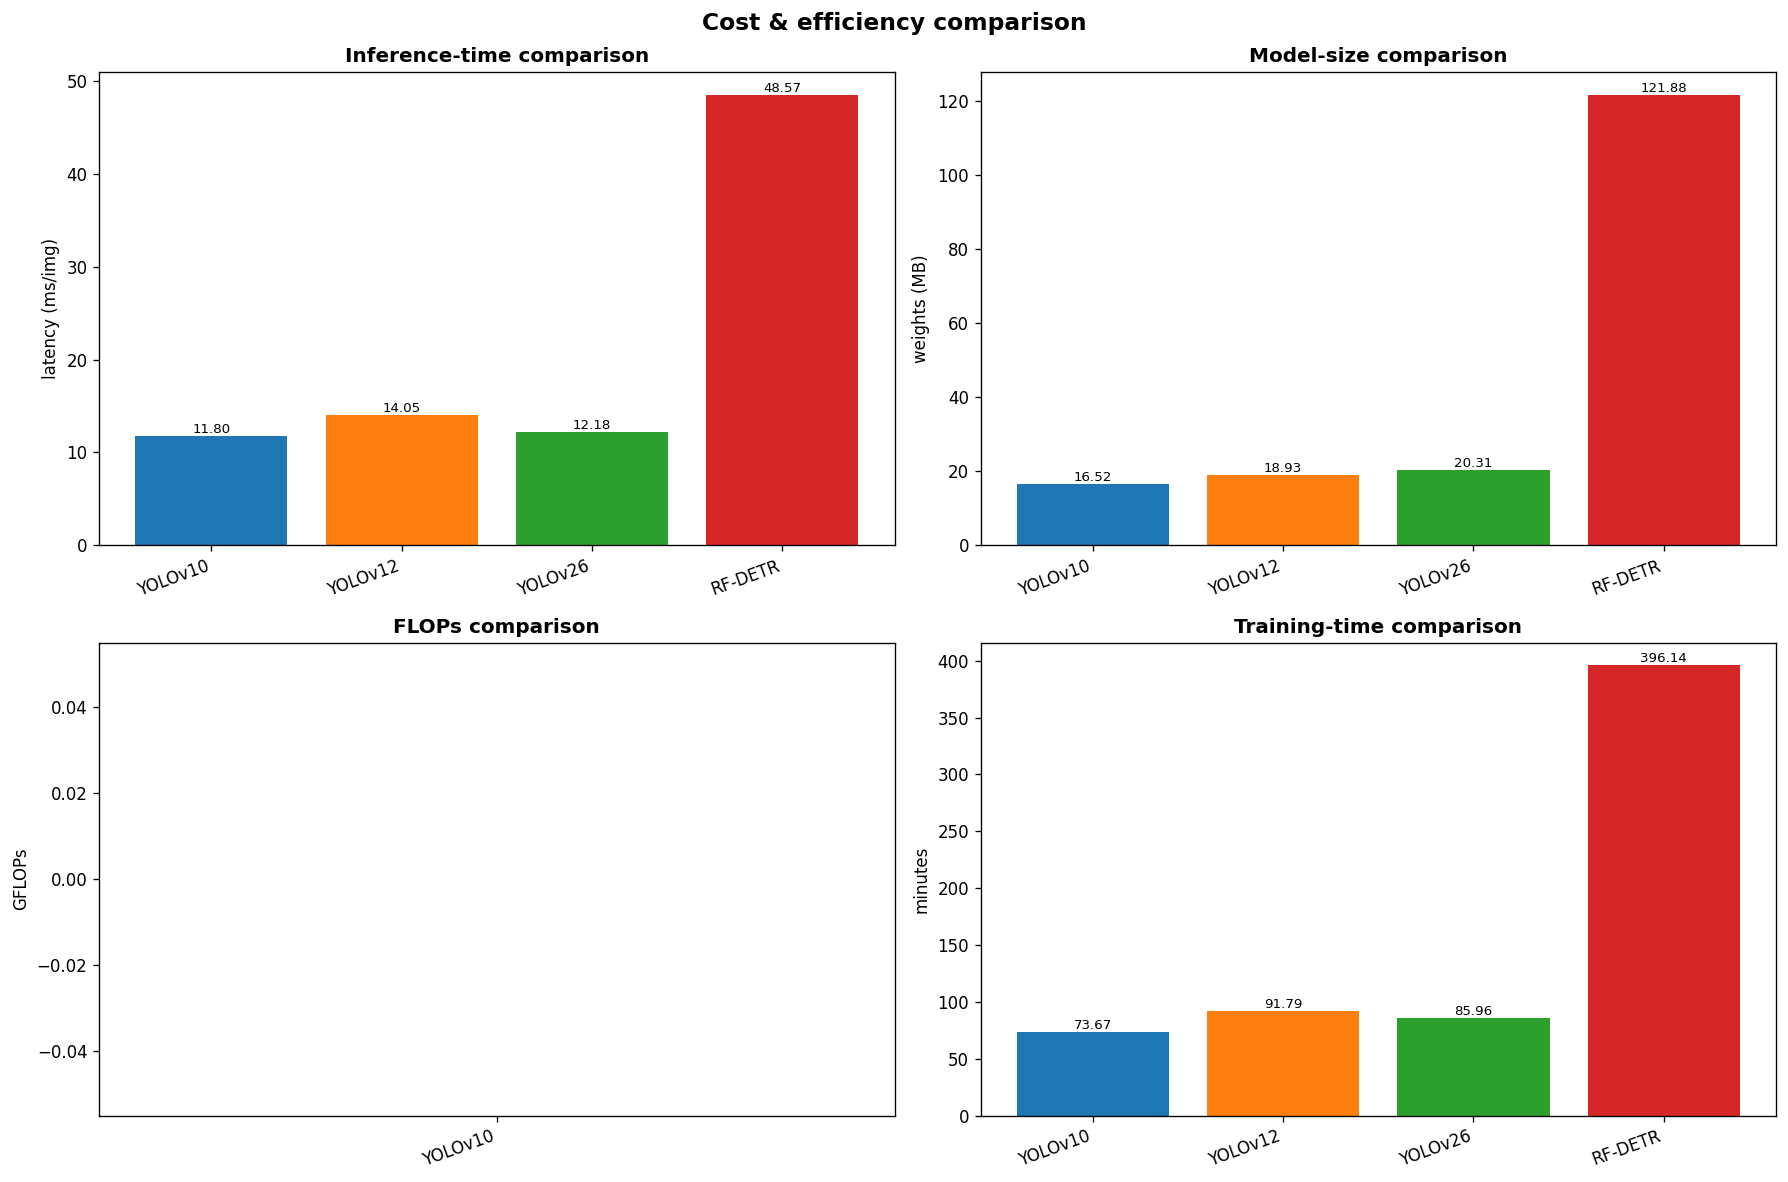

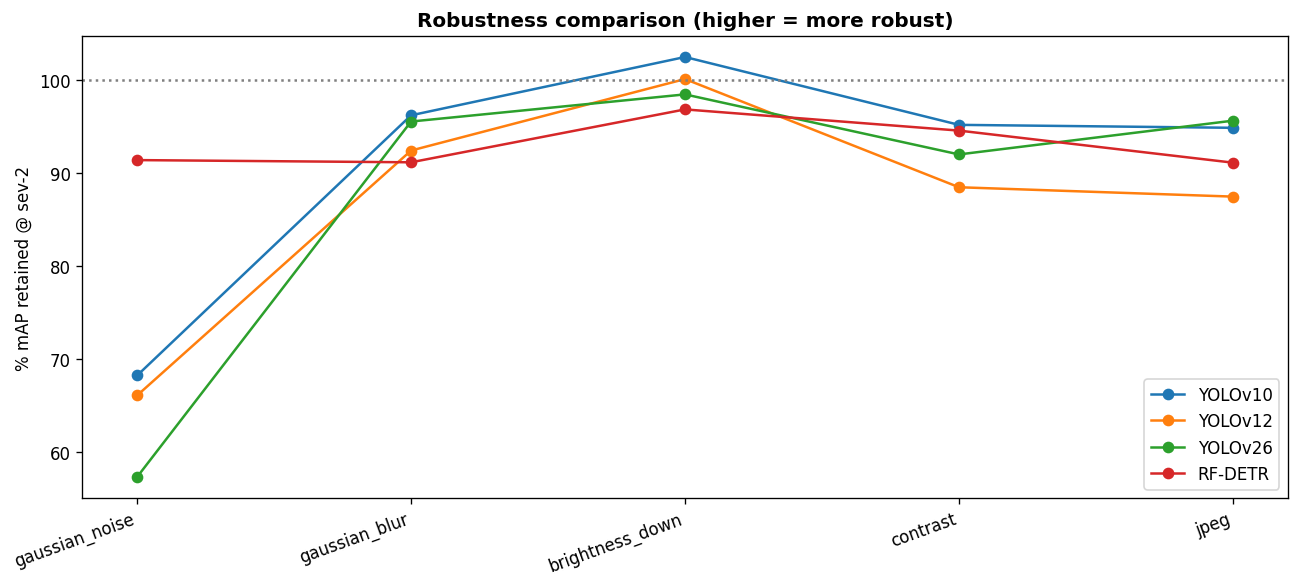


Highest mAP@50:95 : RF-DETR (0.526)
Fastest (FPS)     : YOLOv10 (84.7)
Deployment pick depends on the target: accuracy-bound -> the former; latency-bound -> the latter.


In [16]:
# Gather results_*.json from the shared drop + any attached notebook outputs
search_dirs=[COMPARE_DIR, pathlib.Path("/kaggle/input"), pathlib.Path("/kaggle/working")]
found={}
for d in search_dirs:
    if not d.exists(): continue
    for jf in d.rglob("results_*.json"):
        try: data=json.load(open(jf))
        except Exception: continue
        slug=data.get("model_slug")
        if slug and slug not in found: found[slug]=data
order=["yolov10","yolov12","yolov26","rfdetr"]
rows=[found[s] for s in order if s in found]+[v for k,v in found.items() if k not in order]
print("Models found:", [r["model_key"] for r in rows])
if not rows:
    print("No results_*.json found. Run/attach Notebooks 2-5 outputs.")
else:
    tbl=pd.DataFrame([{
        "Model":r["model_key"],"mAP@50":r.get("map50"),"mAP@50:95":r.get("map5095"),
        "Precision":r.get("precision"),"Recall":r.get("recall"),"F1":r.get("f1"),
        "FPS":r.get("fps_infer"),"Latency(ms)":r.get("latency_ms"),
        "Params(M)":r.get("params_millions"),"GFLOPs":r.get("gflops"),
        "Size(MB)":r.get("size_mb"),"Train(min)":r.get("train_minutes"),
    } for r in rows]).set_index("Model").round(3)
    print("\n=== MODEL COMPARISON TABLE ==="); 
    try: display(tbl)
    except Exception: print(tbl)

    M=[r["model_key"] for r in rows]; cols=plt.cm.tab10(np.arange(len(M)))
    def bar(ax,vals,title,ylabel):
        v=[np.nan if x is None else x for x in vals]
        ax.bar(M,v,color=cols); ax.set_title(title,fontweight="bold"); ax.set_ylabel(ylabel)
        ax.set_xticklabels(M,rotation=20,ha="right")
        for i,x in enumerate(v):
            if x==x: ax.text(i,x,f"{x:.2f}",ha="center",va="bottom",fontsize=8)

    # mAP bar chart (grouped)
    fig,ax=plt.subplots(figsize=(11,5)); x=np.arange(len(M)); w=0.38
    ax.bar(x-w/2,[r.get("map50") for r in rows],w,label="mAP@50")
    ax.bar(x+w/2,[r.get("map5095") for r in rows],w,label="mAP@50:95")
    ax.set_xticks(x); ax.set_xticklabels(M,rotation=20,ha="right"); ax.set_ylabel("mAP")
    ax.set_title("mAP comparison",fontweight="bold"); ax.legend(); plt.tight_layout(); plt.show()

    # Scatters
    fig,ax=plt.subplots(1,3,figsize=(19,5.5))
    for i,r in enumerate(rows):
        ax[0].scatter(r.get("fps_infer"),r.get("map5095"),s=140,color=cols[i]); ax[0].annotate(r["model_key"],(r.get("fps_infer"),r.get("map5095")),fontsize=8)
        ax[1].scatter(r.get("latency_ms"),r.get("map5095"),s=140,color=cols[i]); ax[1].annotate(r["model_key"],(r.get("latency_ms"),r.get("map5095")),fontsize=8)
        p=r.get("params_millions"); ax[2].scatter(p,r.get("map5095"),s=140,color=cols[i])
        if p is not None: ax[2].annotate(r["model_key"],(p,r.get("map5095")),fontsize=8)
    ax[0].set_xlabel("FPS"); ax[0].set_ylabel("mAP@50:95"); ax[0].set_title("FPS vs mAP",fontweight="bold")
    ax[1].set_xlabel("Latency (ms)"); ax[1].set_ylabel("mAP@50:95"); ax[1].set_title("Latency vs Accuracy",fontweight="bold")
    ax[2].set_xlabel("Params (M)"); ax[2].set_ylabel("mAP@50:95"); ax[2].set_title("Parameters vs mAP",fontweight="bold")
    plt.tight_layout(); plt.show()

    # Cost/time bars
    fig,ax=plt.subplots(2,2,figsize=(15,10))
    bar(ax[0,0],[r.get("latency_ms") for r in rows],"Inference-time comparison","latency (ms/img)")
    bar(ax[0,1],[r.get("size_mb") for r in rows],"Model-size comparison","weights (MB)")
    bar(ax[1,0],[r.get("gflops") for r in rows],"FLOPs comparison","GFLOPs")
    bar(ax[1,1],[r.get("train_minutes") for r in rows],"Training-time comparison","minutes")
    plt.suptitle("Cost & efficiency comparison",fontsize=14,fontweight="bold"); plt.tight_layout(); plt.show()

    # Robustness overlay (retained @ sev-2)
    fig,axr=plt.subplots(figsize=(11,5)); corr_keys=None
    for i,r in enumerate(rows):
        ret=r.get("robust_retained_sev2") or {}
        if not ret: continue
        corr_keys=list(ret.keys())
        axr.plot(corr_keys,[ret[k] for k in corr_keys],marker="o",label=r["model_key"],color=cols[i])
    if corr_keys:
        axr.axhline(100,color="grey",ls=":"); axr.set_ylabel("% mAP retained @ sev-2")
        axr.set_title("Robustness comparison (higher = more robust)",fontweight="bold")
        axr.set_xticklabels(corr_keys,rotation=20,ha="right"); axr.legend(); plt.tight_layout(); plt.show()

    # Verdict
    best_acc=max(rows,key=lambda r:r.get("map5095") or -1)
    best_fps=max(rows,key=lambda r:r.get("fps_infer") or -1)
    print(f"\nHighest mAP@50:95 : {best_acc['model_key']} ({best_acc.get('map5095'):.3f})")
    print(f"Fastest (FPS)     : {best_fps['model_key']} ({best_fps.get('fps_infer'):.1f})")
    print("Deployment pick depends on the target: accuracy-bound -> the former; latency-bound -> the latter.")
